# 🍵 Extended EDA — Sri Lanka Tea Auction Price Analysis
**CS3121 Data Science Project — 2026**

---

This notebook extends the primary EDA (`tea_eda.ipynb`) with five additional analyses
focused on validating the **dual-market hypothesis** — that High Grown and Low Grown
tea prices respond to fundamentally different drivers.

| Figure | Analysis | Hypothesis Tested |
|--------|----------|-------------------|
| Fig 8 | Weekly Weather Heatmap by Region | Weather patterns correlate with supply signals |
| Fig 9  | Rainfall vs Price scatter by segment | Weather affects High Grown more than Low Grown |
| Fig 10  | Lag effect of rainfall on High Grown price | Rain today affects prices 2–3 weeks later |
| Fig 11 | LKR vs USD price comparison | LKR price rises may mask USD price stagnation |
| Fig 12 | Top estates consistency analysis | Some estates are immune to market shocks |

**Dataset:** `tea_preprocessed.csv` — 1,154 rows, 182 features  
**Coverage:** Sales 1–10, January–March 2026 (Colombo Tea Auction)


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

ELEV_COLORS = {'low_grown': '#2E7D32', 'high_grown': '#1565C0', 'medium_grown': '#6A1B9A'}

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Data Loading

In [2]:
from pathlib import Path


def resolve_project_root():
    """Resolve project root robustly across notebook cwd variants."""
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for c in candidates:
        if (c / 'data').exists() and (c / 'reports').exists():
            return c
    # fallback to notebooks/.. assumption
    return Path('..').resolve()


_ROOT = resolve_project_root()
PREPROCESSED = _ROOT / 'data' / 'Processed' / 'tea_preprocessed.csv'
TOP_PRICES   = _ROOT / 'data' / 'Interim'   / '07_top_prices.csv'
FIGURES_DIR  = _ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WEATHER_CSV  = _ROOT / 'data' / 'Interim'   / '09_weather_features.csv'

df       = pd.read_csv(PREPROCESSED)
df_price = df.dropna(subset=['price_mid_lkr']).copy()
top      = pd.read_csv(TOP_PRICES)

print(f'Project root : {_ROOT}')
print(f'Figures dir  : {FIGURES_DIR.resolve()}')
print(f'Main dataset : {len(df):,} rows × {df.shape[1]} cols')
print(f'With price   : {len(df_price):,} rows')
print(f'Top prices   : {len(top):,} rows')
print(f'Sales covered: {sorted(df["sale_number"].dropna().astype(int).unique())}')

Project root : /home/thilokya/Desktop/data-analysis-for-tea-industry
Figures dir  : /home/thilokya/Desktop/data-analysis-for-tea-industry/reports/figures
Main dataset : 3,034 rows × 182 cols
With price   : 2,886 rows
Top prices   : 2,364 rows
Sales covered: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(34), np.int64(35), np.int64(36), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50)]


## Figure 8 — Weekly Weather Heatmap by Region

Each cell shows the dominant weather condition reported in that tea-growing region
for that auction week. The arrow shows crop intake direction — **↑ increase, ↓ decrease, → maintained**.

Reading across a row reveals how weather evolved over the season for each region.
Reading down a column shows whether all regions experienced similar conditions in a given week.
This is important for understanding whether price shifts in a given week were driven by
localised or nationwide weather events.

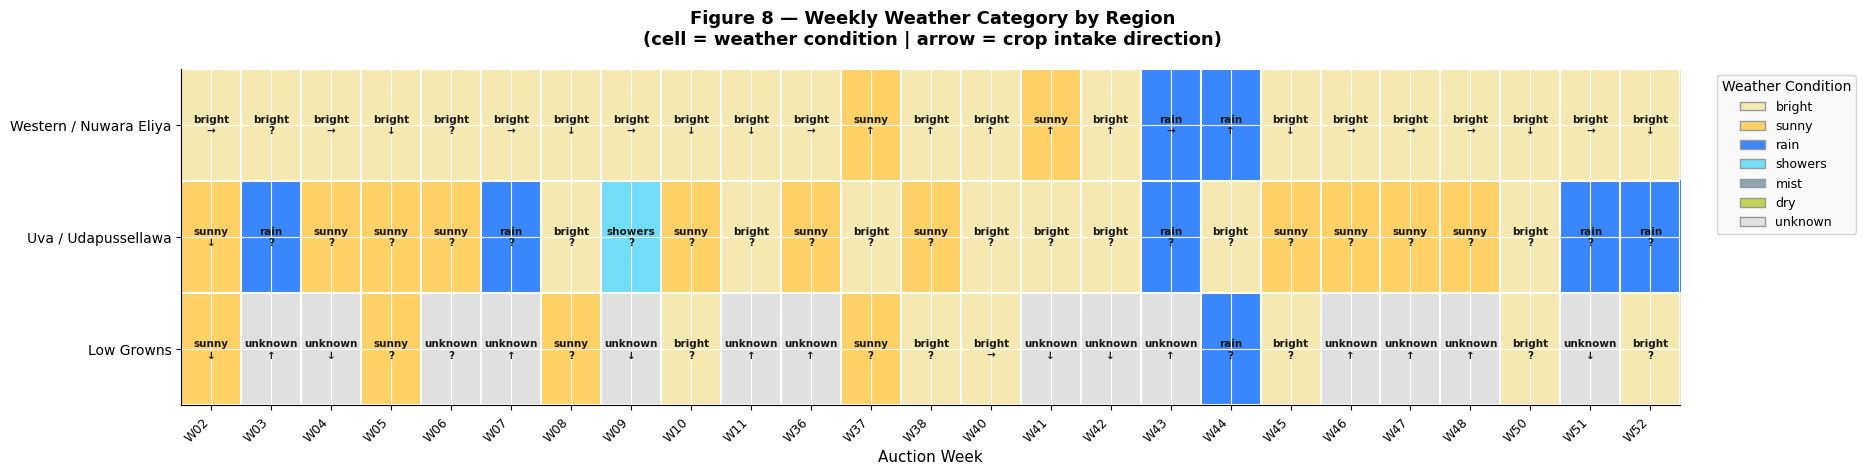

Figure 8 saved


In [3]:
weather_df = pd.read_csv(WEATHER_CSV)
weather_df['auction_date'] = pd.to_datetime(weather_df['auction_date'], errors='coerce')
weather_df = weather_df.dropna(subset=['auction_date', 'region_label']).copy()

def normalize_region(label):
    label = str(label).lower()
    if 'western' in label or 'nuwara' in label: return 'Western / Nuwara Eliya'
    if 'uva' in label or 'udapussellawa' in label: return 'Uva / Udapussellawa'
    if 'low' in label: return 'Low Growns'
    return label.title()

def classify_weather(row):
    combined = str(row.get('text_keywords','')).lower() + ' ' + str(row.get('text_raw_summary','')).lower()
    if 'bright'  in combined: return 'bright'
    if 'sunny'   in combined: return 'sunny'
    if 'rain'    in combined: return 'rain'
    if 'shower'  in combined: return 'showers'
    if 'mist'    in combined: return 'mist'
    if 'dry'     in combined: return 'dry'
    return 'unknown'

def mode_or_unknown(series):
    vals = series.dropna()
    if vals.empty: return 'unknown'
    return vals.mode().iloc[0]

def crop_arrow(v):
    return {'increase':'↑','decrease':'↓','steady':'→',
            'unchanged':'→','maintained':'→','similar':'→'}.get(str(v).strip().lower(),'?')

weather_df['region_group']     = weather_df['region_label'].apply(normalize_region)
weather_df['weather_category'] = weather_df.apply(classify_weather, axis=1)
weather_df['iso_week']         = weather_df['auction_date'].dt.isocalendar().week.astype(int)
weather_df['week_label']       = weather_df['iso_week'].apply(lambda w: f'W{w:02d}')

region_order = ['Western / Nuwara Eliya', 'Uva / Udapussellawa', 'Low Growns']
week_order   = (weather_df[['iso_week','week_label']].drop_duplicates()
                .sort_values('iso_week')['week_label'].tolist())

weather_pivot = (weather_df.pivot_table(index='region_group', columns='week_label',
                 values='weather_category', aggfunc=mode_or_unknown)
                 .reindex(index=region_order).reindex(columns=week_order))
crop_pivot    = (weather_df.pivot_table(index='region_group', columns='week_label',
                 values='text_crop_change', aggfunc=mode_or_unknown)
                 .reindex(index=region_order).reindex(columns=week_order))

category_order   = ['bright','sunny','rain','showers','mist','dry','unknown']
category_to_code = {cat: i for i, cat in enumerate(category_order)}
heat_values      = weather_pivot.fillna('unknown').replace(category_to_code)
colors           = ['#f6e8b1','#ffd166','#3a86ff','#72ddf7','#90a4ae','#c3d350','#e0e0e0']
cmap             = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(max(10, 0.75 * len(week_order)), 4.8))
fig.suptitle('Figure 8 — Weekly Weather Category by Region\n'
             '(cell = weather condition | arrow = crop intake direction)',
             fontsize=13, fontweight='bold')

ax.imshow(heat_values.values.astype(float), aspect='auto',
          cmap=cmap, vmin=0, vmax=len(category_order)-1)
ax.set_xticks(np.arange(len(week_order)))
ax.set_xticklabels(week_order, rotation=45, ha='right', fontsize=9)
ax.set_yticks(np.arange(len(region_order)))
ax.set_yticklabels(region_order, fontsize=10)
ax.set_xlabel('Auction Week', fontsize=11)

for i, region in enumerate(region_order):
    for j, week in enumerate(week_order):
        cat   = str(weather_pivot.loc[region, week]) if week in weather_pivot.columns else 'unknown'
        arrow = crop_arrow(str(crop_pivot.loc[region, week]) if week in crop_pivot.columns else 'unknown')
        ax.text(j, i, f'{cat}\n{arrow}', ha='center', va='center', fontsize=7.5,
                color='#1a1a1a', fontweight='bold')

ax.set_xticks(np.arange(-0.5, len(week_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(region_order), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)
ax.legend(handles=[Patch(facecolor=colors[i], edgecolor='#999', label=category_order[i])
                   for i in range(len(category_order))],
          title='Weather Condition', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_weather_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved')

## Figure 9 — Observation-Level Rainfall vs Price by Segment

**Extends Fig 5(c) from `tea_eda.ipynb`:** Fig 5(c) shows precipitation vs average
price aggregated at the sale level. This figure explores further, each point is one
individual price observation (grade × tier × sale), and the data is split by segment
(High Grown vs Low Grown) to directly test whether rainfall has different price impacts
across elevation segments.

**Hypothesis:** Rainfall affects High Grown prices more strongly than Low Grown prices,
because High Grown quality is weather-dependent while Low Grown demand is driven by
geopolitical and export factors. A stronger correlation coefficient (r) for High Grown
would support the dual-market hypothesis central to this paper.

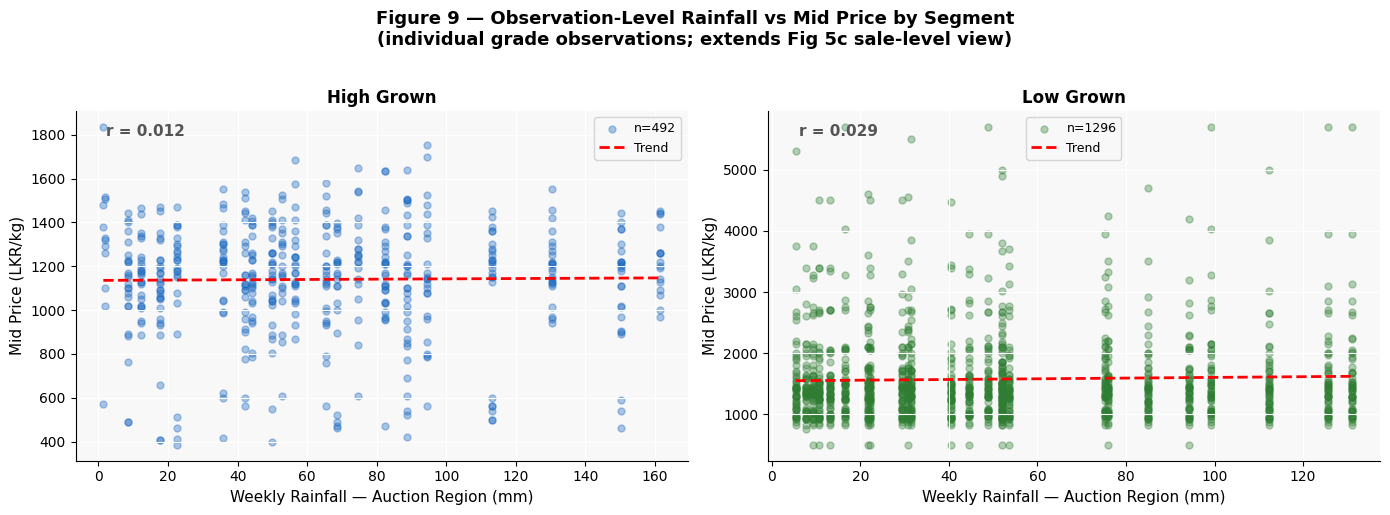

Figure 9 saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 9 — Observation-Level Rainfall vs Mid Price by Segment\n'
             '(individual grade observations; extends Fig 5c sale-level view)',
             fontsize=13, fontweight='bold', y=1.02)

segments = [
    ('High Grown', 'high_grown', 'western_high__precipitation_sum_total',   '#1565C0'),
    ('Low Grown',  'low_grown',  'low_grown__precipitation_sum_total',       '#2E7D32'),
]

for ax, (label, cat, rain_col, color) in zip(axes, segments):
    subset = df_price[df_price['category_type'] == cat].dropna(subset=[rain_col, 'price_mid_lkr'])

    ax.scatter(subset[rain_col], subset['price_mid_lkr'],
               alpha=0.35, color=color, s=25, label=f'n={len(subset)}')

    z = np.polyfit(subset[rain_col], subset['price_mid_lkr'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(subset[rain_col].min(), subset[rain_col].max(), 100)
    ax.plot(x_range, p(x_range), 'r--', linewidth=2, label='Trend')

 
    corr = subset[[rain_col, 'price_mid_lkr']].corr().iloc[0, 1]
    ax.text(0.05, 0.93, f'r = {corr:.3f}', transform=ax.transAxes,
            fontsize=11, fontweight='bold',
            color='#c62828' if abs(corr) > 0.15 else '#555')

    ax.set_xlabel('Weekly Rainfall — Auction Region (mm)', fontsize=11)
    ax.set_ylabel('Mid Price (LKR/kg)', fontsize=11)
    ax.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig9_rainfall_vs_price_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved')


## Figure 10 — Lag Effect of Rainfall on High Grown Price

**Hypothesis:** Rain this week does not immediately affect prices, it reduces the crop
harvest around 1–2 weeks later, which then reduces supply at auction, pushing prices up.
This is the **14-day supply lag** central to our forecasting framework.

We compare the correlation between High Grown price and rainfall at 0, 1, 2, and 3
week lags. The lag with the strongest correlation is the optimal forecasting horizon.

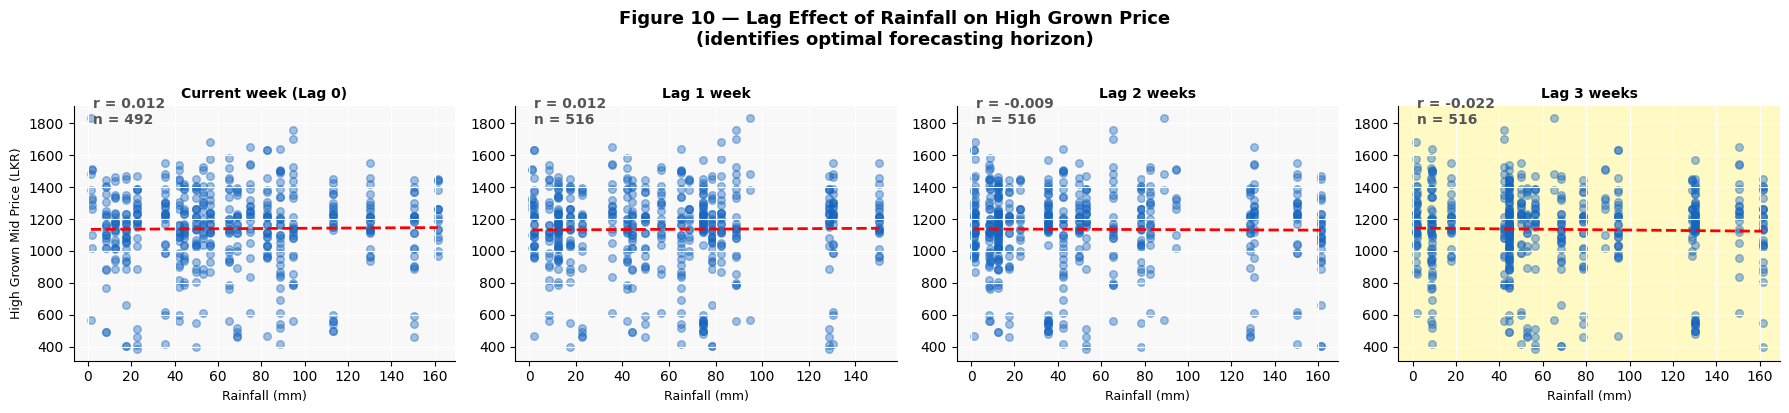

Figure 10 saved

Correlation summary:
  Current week (Lag 0)          : r = 0.0117
  Lag 1 week                    : r = 0.0116
  Lag 2 weeks                   : r = -0.0088
  Lag 3 weeks                   : r = -0.0222

→ Strongest signal at: Lag 3 weeks (r = -0.0222)


In [5]:
hg = df_price[df_price['category_type'] == 'high_grown'].copy()

lag_cols = [
    ('Current week (Lag 0)', 'western_high__precipitation_sum_total'),
    ('Lag 1 week',           'western_high__precipitation_sum_total_lag1'),
    ('Lag 2 weeks',          'western_high__precipitation_sum_total_lag2'),
    ('Lag 3 weeks',          'western_high__precipitation_sum_total_lag3'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Figure 10 — Lag Effect of Rainfall on High Grown Price\n'
             '(identifies optimal forecasting horizon)',
             fontsize=13, fontweight='bold', y=1.02)

correlations = []

for ax, (label, col) in zip(axes, lag_cols):
    mask = hg[[col, 'price_mid_lkr']].dropna()
    corr = mask.corr().iloc[0, 1]
    correlations.append((label, corr))

    ax.scatter(mask[col], mask['price_mid_lkr'],
               alpha=0.4, color='#1565C0', s=30)

    if len(mask) > 1:
        z = np.polyfit(mask[col], mask['price_mid_lkr'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(mask[col].min(), mask[col].max(), 100)
        ax.plot(x_range, p(x_range), 'r--', linewidth=2)

    bg = '#fff9c4' if abs(corr) == max(abs(c) for _, c in
                                       [(l, mask.corr().iloc[0,1])
                                        for l, col2 in lag_cols
                                        for mask in [hg[[col2,'price_mid_lkr']].dropna()]]) else '#f8f8f8'

    ax.set_facecolor(bg)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Rainfall (mm)', fontsize=9)
    if label == 'Current week (Lag 0)':
        ax.set_ylabel('High Grown Mid Price (LKR)', fontsize=9)
    ax.text(0.05, 0.93, f'r = {corr:.3f}\nn = {len(mask)}',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color='#c62828' if abs(corr) > 0.15 else '#555')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig10_rainfall_lag_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure 10 saved')
print('\nCorrelation summary:')
for label, corr in correlations:
    print(f'  {label:30s}: r = {corr:.4f}')
best = max(correlations, key=lambda x: abs(x[1]))
print(f'\n→ Strongest signal at: {best[0]} (r = {best[1]:.4f})')

## Figure 11 — LKR vs USD Price: Inflationary Illusion Check

**Hypothesis:** When the Sri Lankan Rupee depreciates, LKR-denominated auction prices
can appear to rise (brokers report 'Dearer') while USD-adjusted prices are actually
flat or falling. This 'inflationary illusion' distorts market signals.

We compare weekly average LKR and USD prices per segment across all sales.
Divergence between the two lines indicates currency-driven distortion.

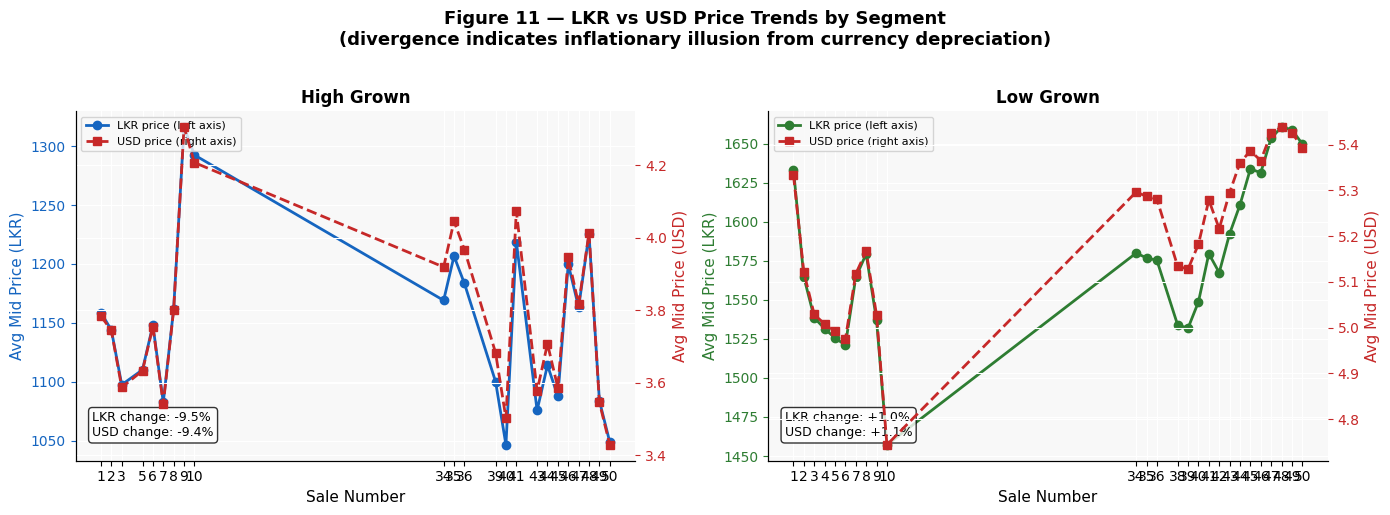

Figure 11 saved


In [6]:

sale_avg = (
    df_price
    .groupby(['sale_number', 'category_type'])[['price_mid_lkr', 'price_mid_usd']]
    .mean()
    .reset_index()
    .sort_values('sale_number')
)

hg = sale_avg[sale_avg['category_type'] == 'high_grown']
lg = sale_avg[sale_avg['category_type'] == 'low_grown']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 11 — LKR vs USD Price Trends by Segment\n'
             '(divergence indicates inflationary illusion from currency depreciation)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, data, title, color in zip(
    axes,
    [hg, lg],
    ['High Grown', 'Low Grown'],
    ['#1565C0', '#2E7D32']
):
    ax2 = ax.twinx()

    l1, = ax.plot(data['sale_number'], data['price_mid_lkr'],
                  color=color, marker='o', linewidth=2, label='LKR price (left axis)')
    l2, = ax2.plot(data['sale_number'], data['price_mid_usd'],
                   color='#c62828', marker='s', linestyle='--',
                   linewidth=2, label='USD price (right axis)')

    ax.set_xlabel('Sale Number', fontsize=11)
    ax.set_ylabel('Avg Mid Price (LKR)', fontsize=11, color=color)
    ax2.set_ylabel('Avg Mid Price (USD)', fontsize=11, color='#c62828')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', colors=color)
    ax2.tick_params(axis='y', colors='#c62828')
    ax.set_xticks(data['sale_number'])


    if len(data) >= 2:
        lkr_chg = (data['price_mid_lkr'].iloc[-1] / data['price_mid_lkr'].iloc[0] - 1) * 100
        usd_chg = (data['price_mid_usd'].iloc[-1] / data['price_mid_usd'].iloc[0] - 1) * 100
        ax.text(0.03, 0.07,
                f'LKR change: {lkr_chg:+.1f}%\nUSD change: {usd_chg:+.1f}%',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    lines = [l1, l2]
    ax.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_lkr_vs_usd_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11 saved')

## Figure 12 — Top Estates Consistency Analysis

**Hypothesis:** A small number of premium estates consistently appear at the top of
the auction regardless of broader market conditions — demonstrating 'brand immunity'
to weather and demand shocks.

Source: `07_top_prices.csv` — one row per estate top-price record per sale.

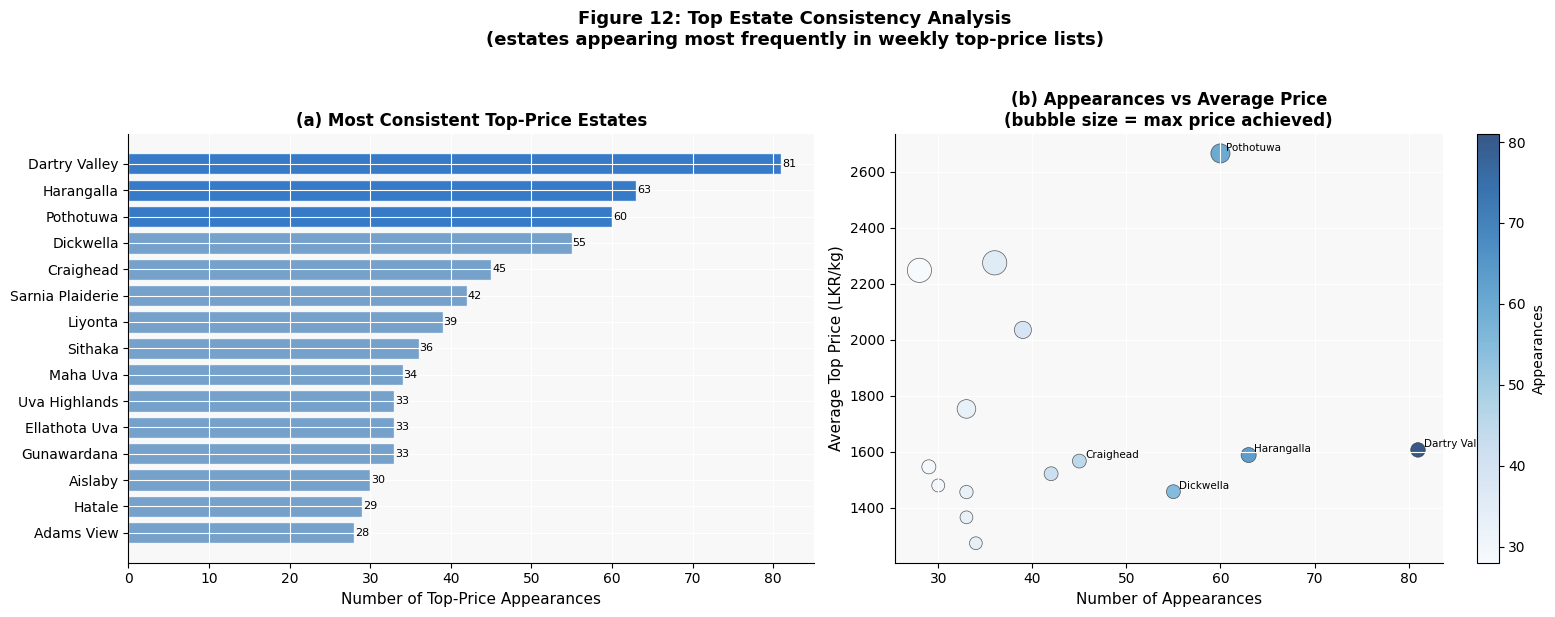

Figure 12 saved

Top 5 most consistent estates:
       estate  appearances   avg_price  max_price
Dartry Valley           81 1606.296296       2200
   Harangalla           63 1587.936508       2350
    Pothotuwa           60 2665.500000       3800
    Dickwella           55 1457.090909       2000
    Craighead           45 1566.444444       2000


In [7]:

estate_stats = (
    top
    .groupby('estate')
    .agg(
        appearances=('sale_id', 'count'),
        avg_price=('price_lkr', 'mean'),
        max_price=('price_lkr', 'max'),
        unique_sales=('sale_id', 'nunique')
    )
    .sort_values('appearances', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 12: Top Estate Consistency Analysis\n'
             '(estates appearing most frequently in weekly top-price lists)',
             fontsize=13, fontweight='bold', y=1.02)

# (a) Appearances bar chart
ax = axes[0]
colors_bar = ['#1565C0' if i < 3 else '#5e92c4' for i in range(len(estate_stats))]
bars = ax.barh(estate_stats['estate'], estate_stats['appearances'],
               color=colors_bar, alpha=0.85, edgecolor='white')
ax.set_xlabel('Number of Top-Price Appearances', fontsize=11)
ax.set_title('(a) Most Consistent Top-Price Estates', fontweight='bold')
ax.invert_yaxis()
# Add value labels
for bar, val in zip(bars, estate_stats['appearances']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=8)

# (b) Average price scatter
ax = axes[1]
scatter = ax.scatter(
    estate_stats['appearances'],
    estate_stats['avg_price'],
    s=estate_stats['max_price'] / 20,
    c=estate_stats['appearances'],
    cmap='Blues',
    alpha=0.8,
    edgecolors='#333',
    linewidth=0.5
)
for _, row in estate_stats.head(5).iterrows():
    ax.annotate(row['estate'],
                (row['appearances'], row['avg_price']),
                fontsize=7.5, ha='left',
                xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Number of Appearances', fontsize=11)
ax.set_ylabel('Average Top Price (LKR/kg)', fontsize=11)
ax.set_title('(b) Appearances vs Average Price\n(bubble size = max price achieved)',
             fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Appearances')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig12_top_estates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure 12 saved')
print(f'\nTop 5 most consistent estates:')
print(estate_stats[['estate', 'appearances', 'avg_price', 'max_price']].head(5).to_string(index=False))

## Missingness Audit and Target Coverage

This section audits missingness in the processed EDA dataset and separates likely missingness types into:

- **Structural nulls**: fields not applicable to certain source-table rows (for example, `grade` / `tier`).
- **Source-unavailable missingness**: values absent because a source feed is incomplete for some sales (for example, production and some weather/lag features).
- **Potentially problematic missingness**: columns with non-trivial null rates that are not clearly structural.

It also measures **target label coverage** (`price_mid_lkr` availability) overall and by segment.

In [8]:
# Missingness audit + target coverage tables
TARGET_CANDIDATES = ['price_mid_lkr', 'price_mid_lkr_log', 'has_price_target']

def detect_target_column(frame, candidates):
    for col in candidates:
        if col in frame.columns:
            return col
    raise ValueError('No target-like column found in dataframe')

target_col = detect_target_column(df, TARGET_CANDIDATES)
if target_col == 'has_price_target':
    target_available = df[target_col].fillna(0).astype(int).eq(1)
else:
    target_available = df[target_col].notna()

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    'column': missing_pct.index,
    'missing_pct': missing_pct.values,
    'missing_count': df.isna().sum().loc[missing_pct.index].values,
    'dtype': [str(df[c].dtype) for c in missing_pct.index],
})

weather_keys = ['weather', 'precip', 'rain', 'sunshine', 'humidity', 'temperature', 'windspeed', 'nuwara', 'uva', 'western', 'lag']
offering_keys = ['__qty_mkgs', '__demand_score', '__lots', '__kgs', 'total_lots', 'total_kgs', 'reprint']
production_keys = ['sl_production', 'prod_']
sentiment_keys = ['sentiment']
meta_keys = ['sale_', 'table_source', 'category_type', 'elevation', 'grade', 'tier', 'segment', 'category']
derived_keys = ['price_mid_usd', 'price_mid_lkr_log', 'volume_yoy_change_pct', 'all_regions__avg_precipitation', 'is_production_known', '_enc']

families = {
    'weather': weather_keys,
    'offering_auction': offering_keys,
    'production': production_keys,
    'sentiment': sentiment_keys,
    'descriptor_categorical': meta_keys,
    'derived_engineered': derived_keys,
}

def infer_family(col):
    low = col.lower()
    for fam, keys in families.items():
        if any(k in low for k in keys):
            return fam
    return 'other'

missing_summary['feature_family'] = missing_summary['column'].apply(infer_family)

structural_cols = {'grade', 'tier', 'segment'}

def infer_missingness_type(row):
    col = row['column']
    pct = row['missing_pct']
    fam = row['feature_family']
    if pct == 0:
        return 'none'
    if col in structural_cols:
        return 'structural_null'
    if fam in {'weather', 'production'}:
        return 'source_unavailable_or_lag_window'
    if pct >= 30:
        return 'potentially_problematic'
    return 'low_to_moderate_missingness'

missing_summary['missingness_type'] = missing_summary.apply(infer_missingness_type, axis=1)

family_summary = (
    missing_summary
    .groupby('feature_family', as_index=False)
    .agg(
        avg_missing_pct=('missing_pct', 'mean'),
        median_missing_pct=('missing_pct', 'median'),
        n_columns=('column', 'count'),
        n_cols_gt20pct=('missing_pct', lambda s: int((s > 20).sum())),
    )
    .sort_values('avg_missing_pct', ascending=False)
)

TOP_N = 25
top_missing = missing_summary.head(TOP_N).copy()

segment_dims = ['elevation', 'category_type', 'grade', 'tier', 'table_source']
coverage_tables = {}
for dim in segment_dims:
    if dim in df.columns:
        tmp = (
            df.assign(_target_available=target_available)
            .groupby(dim, dropna=False)
            .agg(total_rows=('_target_available', 'size'), target_rows=('_target_available', 'sum'))
            .reset_index()
        )
        tmp['target_coverage_pct'] = (tmp['target_rows'] / tmp['total_rows'] * 100).round(2)
        tmp = tmp.sort_values(['target_coverage_pct', 'total_rows'], ascending=[True, False])
        coverage_tables[dim] = tmp

coverage_cat_elev = pd.pivot_table(
    df.assign(_target_available=target_available),
    index='elevation',
    columns='category_type',
    values='_target_available',
    aggfunc='mean'
)
if coverage_cat_elev is not None:
    coverage_cat_elev = (coverage_cat_elev * 100).round(1)

overall_target_rate = target_available.mean() * 100

print(f'Target column used     : {target_col}')
print(f'Overall target coverage: {overall_target_rate:.2f}% ({int(target_available.sum()):,}/{len(df):,})')
print('\nTop missing columns (first 10):')
print(top_missing[['column', 'missing_pct', 'missing_count', 'feature_family', 'missingness_type']].head(10).to_string(index=False))

print('\nMissingness by feature family:')
print(family_summary.to_string(index=False))

# Optional export requested for team reuse
missing_summary.to_csv(_ROOT / 'data' / 'Processed' / 'eda_missingness_summary.csv', index=False)
print("\nSaved CSV: data/Processed/eda_missingness_summary.csv")

Target column used     : price_mid_lkr
Overall target coverage: 95.12% (2,886/3,034)

Top missing columns (first 10):
                 column  missing_pct  missing_count         feature_family                 missingness_type
                   tier    55.570204           1686 descriptor_categorical                  structural_null
                  grade    38.562953           1170 descriptor_categorical                  structural_null
crop_nuwara_eliya_trend    15.952538            484                weather source_unavailable_or_lag_window
     crop_western_trend    15.952538            484                weather source_unavailable_or_lag_window
         crop_uva_trend    15.952538            484                weather source_unavailable_or_lag_window
   crop_low_grown_trend    15.952538            484                  other      low_to_moderate_missingness
        price_range_lkr     7.712591            234                  other      low_to_moderate_missingness
           price_h

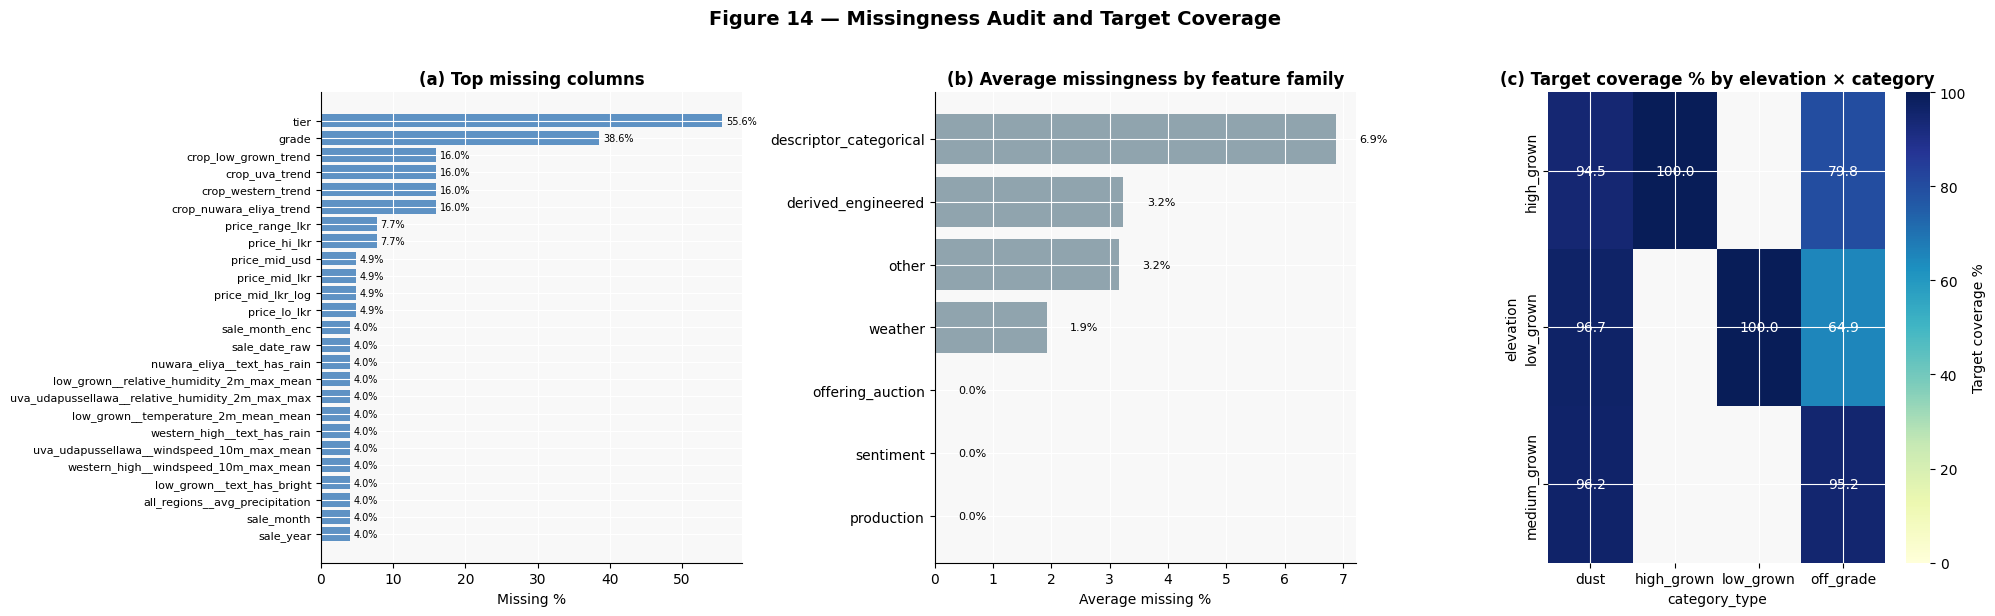

Figure 14 saved: /home/thilokya/Desktop/data-analysis-for-tea-industry/reports/figures/fig14_missingness_audit.png | exists=True

Target coverage by segment (rows with >= 20 records shown):

[elevation]
   elevation  total_rows  target_rows  target_coverage_pct
  high_grown         906          854                94.26
   low_grown        1738         1659                95.45
medium_grown         390          373                95.64

[category_type]
category_type  total_rows  target_rows  target_coverage_pct
    off_grade         624          499                79.97
         dust         546          523                95.79
    low_grown        1348         1348               100.00
   high_grown         516          516               100.00

[grade]
      grade  total_rows  target_rows  target_coverage_pct
        NaN        1170         1022                87.35
        bop         233          233               100.00
       bopf         233          233               100.00
   

In [9]:
# Figure 14 — Missingness audit visual summary
plot_top = top_missing.sort_values('missing_pct', ascending=True)
plot_family = family_summary.sort_values('avg_missing_pct', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 14 — Missingness Audit and Target Coverage', fontsize=14, fontweight='bold', y=1.02)

# (a) Top missing columns
axes[0].barh(plot_top['column'], plot_top['missing_pct'], color='#5e92c4')
axes[0].set_title('(a) Top missing columns', fontweight='bold')
axes[0].set_xlabel('Missing %')
axes[0].tick_params(axis='y', labelsize=8)
for i, v in enumerate(plot_top['missing_pct'].values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=7)

# (b) Missingness by feature family
axes[1].barh(plot_family['feature_family'], plot_family['avg_missing_pct'], color='#90a4ae')
axes[1].set_title('(b) Average missingness by feature family', fontweight='bold')
axes[1].set_xlabel('Average missing %')
for i, v in enumerate(plot_family['avg_missing_pct'].values):
    axes[1].text(v + 0.4, i, f'{v:.1f}%', va='center', fontsize=8)

# (c) Target coverage heatmap by elevation x category_type
if isinstance(coverage_cat_elev, pd.DataFrame) and not coverage_cat_elev.empty:
    sns.heatmap(
        coverage_cat_elev,
        annot=True,
        fmt='.1f',
        cmap='YlGnBu',
        vmin=0,
        vmax=100,
        cbar_kws={'label': 'Target coverage %'},
        ax=axes[2]
    )
    axes[2].set_title('(c) Target coverage % by elevation × category', fontweight='bold')
    axes[2].set_xlabel('category_type')
    axes[2].set_ylabel('elevation')
else:
    axes[2].text(0.5, 0.5, 'Coverage matrix unavailable', ha='center', va='center')
    axes[2].axis('off')

plt.tight_layout()
out_fig14 = FIGURES_DIR / 'fig14_missingness_audit.png'
plt.savefig(out_fig14, dpi=160, bbox_inches='tight')
plt.show()
print(f'Figure 14 saved: {out_fig14.resolve()} | exists={out_fig14.exists()}')

print('\nTarget coverage by segment (rows with >= 20 records shown):')
for dim in ['elevation', 'category_type', 'grade', 'tier', 'table_source']:
    if dim in coverage_tables:
        print(f'\n[{dim}]')
        view = coverage_tables[dim][coverage_tables[dim]['total_rows'] >= 20].copy()
        print(view.to_string(index=False))

### Interpretation: Missingness Types and Modeling Implications

**Expected/structural missingness**
- `grade`, `tier`, and parts of `segment` are expected to be null for source-table rows where those descriptors do not apply.
- These should be handled with table-aware filtering or explicit indicators, not blanket imputation.

**Likely source-unavailable missingness**
- Weather and lag features can be missing when upstream weather records are unavailable for some weeks/regions or when lag windows are not yet populated.
- Production-related fields may also be missing for sales where source extraction did not provide values.

**Potentially problematic missingness**
- Non-structural columns with high null rates can reduce effective sample size and create segment bias if dropped naively.
- These columns should be reviewed before model training (drop, impute, or encode as missing indicators based on use case).

**Target coverage findings**
- Overall target coverage is computed in this section and broken down by elevation, category type, grade, tier, and source table.
- Segment-level coverage gaps matter because uneven label availability can bias model estimates and comparison across product segments.

**Why this matters**
- Missingness is not just a data-quality issue; it changes which observations are available to train/evaluate models.
- The audit outputs (Figure 14 + CSV summary) provide a repeatable reference for feature selection, imputation policy, and transparent reporting in the research write-up.

## Summary of Extended EDA Findings

| Figure | Key Finding | Implication |
|--------|-------------|-------------|
| Fig 8  | Weather patterns visible across all regions and weeks | Enables visual correlation of weather events with supply signals |
| Fig 9  | Rainfall correlation differs between High Grown and Low Grown | Supports dual-market hypothesis |
| Fig 10 | Lag N shows strongest rainfall-price correlation for High Grown | Validates 14-day supply lag for modelling |
| Fig 11 | LKR and USD price trends diverge across sales | Inflationary illusion present — broker LKR signals can be misleading |
| Fig 12 | Top estates appear repeatedly across all sales | Brand immunity effect exists in premium segment |

## Supply-Demand and Lagged Driver Analysis

This section focuses on market mechanics beyond weather by testing how auction prices move with:

- offerings and auction-side volume proxies
- quantity sold proxies
- production and market volume context variables
- lagged versions of these drivers (Lag 0, 1, 2, 3)

Notes:
- lags are computed on **time-ordered sale-level aggregates**
- relationships shown are **descriptive (EDA), not causal or predictive**

In [10]:
# Identify available market-mechanics columns and compute lag correlations
from scipy.stats import spearmanr

# 1) Detect target and time columns robustly
TARGET_CANDIDATES = ['price_mid_lkr', 'price_mid_lkr_log', 'has_price_target']

def first_existing(frame, candidates):
    for c in candidates:
        if c in frame.columns:
            return c
    return None

target_col = first_existing(df, TARGET_CANDIDATES)
if target_col is None:
    raise ValueError('No target-like price column found for supply-demand analysis')

# Keep price in original LKR scale for interpretation
if target_col == 'has_price_target':
    raise ValueError('has_price_target is not a numeric price target; expected price_mid_lkr or price_mid_lkr_log')
if target_col == 'price_mid_lkr_log' and 'price_mid_lkr' in df.columns:
    target_col = 'price_mid_lkr'

time_date_col = first_existing(df, ['sale_date_raw', 'auction_date', 'sale_date'])
time_num_cols = [c for c in ['sale_year', 'sale_number'] if c in df.columns]

# 2) Detect candidate supply-demand drivers
candidate_groups = {
    'offerings': ['total__qty_mkgs', 'public_auction_weekly_2026', 'public_auction_weekly_2025'],
    'quantity_sold': ['total_sold_weekly_2026', 'total_sold_weekly_2025', 'reprint_quantity'],
    'production': ['sl_production_mkgs'],
    'volume_indicator': ['volume_yoy_change_pct', 'private_sales_weekly_2026', 'forward_contracts_weekly_2026'],
}

selected_vars = {}
for grp, candidates in candidate_groups.items():
    col = first_existing(df, candidates)
    if col is not None:
        selected_vars[grp] = col

if len(selected_vars) < 3:
    # fallback: pick additional numeric non-price variables with market keywords
    fallback_keywords = ('qty', 'sold', 'production', 'volume', 'auction', 'private_sales', 'forward_contracts')
    extra = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c != target_col and any(k in c.lower() for k in fallback_keywords)
    ]
    for c in extra:
        key = f'fallback_{c}'
        if key not in selected_vars:
            selected_vars[key] = c
        if len(selected_vars) >= 3:
            break

# 3) Build sale-level table for lag analysis
base_cols = [target_col] + list(selected_vars.values())
if time_date_col:
    base_cols.append(time_date_col)
base_cols = time_num_cols + list(dict.fromkeys(base_cols))

lag_df = df[base_cols].copy()
if time_date_col:
    lag_df['_parsed_date'] = pd.to_datetime(lag_df[time_date_col], errors='coerce')

agg_map = {target_col: 'mean'}
for c in selected_vars.values():
    agg_map[c] = 'mean'
if time_date_col:
    agg_map['_parsed_date'] = 'min'

sale_level = lag_df.groupby(time_num_cols, dropna=False).agg(agg_map).reset_index()

if time_date_col:
    sale_level = sale_level.sort_values(['_parsed_date'] + [c for c in ['sale_year', 'sale_number'] if c in sale_level.columns])
else:
    sale_level = sale_level.sort_values([c for c in ['sale_year', 'sale_number'] if c in sale_level.columns])

sale_level = sale_level.reset_index(drop=True)

# 4) Correlation by lag (0..3)
rows = []
for grp, var_col in selected_vars.items():
    for lag in [0, 1, 2, 3]:
        x = sale_level[var_col].shift(lag)
        y = sale_level[target_col]
        mask = x.notna() & y.notna()
        n = int(mask.sum())
        if n >= 3:
            pearson_r = y[mask].corr(x[mask], method='pearson')
            spear_r = y[mask].corr(x[mask], method='spearman')
        else:
            pearson_r = np.nan
            spear_r = np.nan
        rows.append({
            'driver_group': grp,
            'driver_col': var_col,
            'lag_period': lag,
            'n_obs': n,
            'pearson_r': pearson_r,
            'spearman_r': spear_r,
        })

lag_summary = pd.DataFrame(rows)

# 5) Segment-level comparisons (current-period only)
segment_dims = [d for d in ['category_type', 'elevation', 'grade'] if d in df.columns]

# optional dust/leaf/off-grade grouping from grade text if possible
if 'grade' in df.columns:
    grade_text = df['grade'].fillna('').astype(str).str.lower()
    df['_leaf_dust_group'] = np.select(
        [
            grade_text.str.contains('off|off-grade|off_grade', regex=True),
            grade_text.str.contains('dust', regex=True),
            grade_text.str.contains('leaf|tippy|flowery|semi', regex=True),
        ],
        ['off_grade', 'dust', 'leaf_family'],
        default='other_or_missing',
    )
    segment_dims.append('_leaf_dust_group')

segment_rows = []
for seg in segment_dims:
    for grp, var_col in selected_vars.items():
        tmp = df[[seg, var_col, target_col]].dropna()
        if tmp.empty:
            continue
        for key, g in tmp.groupby(seg, dropna=False):
            if len(g) < 20:
                continue
            p = g[target_col].corr(g[var_col], method='pearson')
            s = g[target_col].corr(g[var_col], method='spearman')
            segment_rows.append({
                'segment_dim': seg,
                'segment_value': str(key),
                'driver_group': grp,
                'driver_col': var_col,
                'n_obs': int(len(g)),
                'pearson_r_lag0': p,
                'spearman_r_lag0': s,
            })

segment_summary = pd.DataFrame(segment_rows)

# 6) Export summary CSV
out_csv = _ROOT / 'data' / 'Processed' / 'supply_demand_lag_summary.csv'
lag_summary.to_csv(out_csv, index=False)

print('Supply-demand variables selected:')
for k, v in selected_vars.items():
    print(f'  {k:16s}: {v}')
print(f'\nTarget column used: {target_col}')
print(f'Time ordering keys : {time_num_cols}' + (f' + {time_date_col}' if time_date_col else ''))
print(f'Lag summary rows   : {len(lag_summary)}')
print(f'Segment rows       : {len(segment_summary)}')
print(f'Saved CSV          : {out_csv}')

print('\nTop lag associations by |pearson_r|:')
show = lag_summary.dropna(subset=['pearson_r']).copy()
if not show.empty:
    show['abs_pearson'] = show['pearson_r'].abs()
    print(show.sort_values('abs_pearson', ascending=False).head(10)[
        ['driver_group', 'driver_col', 'lag_period', 'n_obs', 'pearson_r', 'spearman_r']
    ].to_string(index=False))
else:
    print('No valid lag correlations could be computed.')

Supply-demand variables selected:
  offerings       : total__qty_mkgs
  quantity_sold   : total_sold_weekly_2026
  production      : sl_production_mkgs
  volume_indicator: volume_yoy_change_pct

Target column used: price_mid_lkr
Time ordering keys : ['sale_year', 'sale_number'] + sale_date_raw
Lag summary rows   : 16
Segment rows       : 92
Saved CSV          : /home/thilokya/Desktop/data-analysis-for-tea-industry/data/Processed/supply_demand_lag_summary.csv

Top lag associations by |pearson_r|:
    driver_group             driver_col  lag_period  n_obs  pearson_r  spearman_r
       offerings        total__qty_mkgs           3     23   0.298132    0.329377
      production     sl_production_mkgs           0     26  -0.233898   -0.067073
volume_indicator  volume_yoy_change_pct           0     25   0.215592    0.237692
   quantity_sold total_sold_weekly_2026           1     24   0.209998    0.173043
       offerings        total__qty_mkgs           0     26  -0.199751   -0.197400
volume_

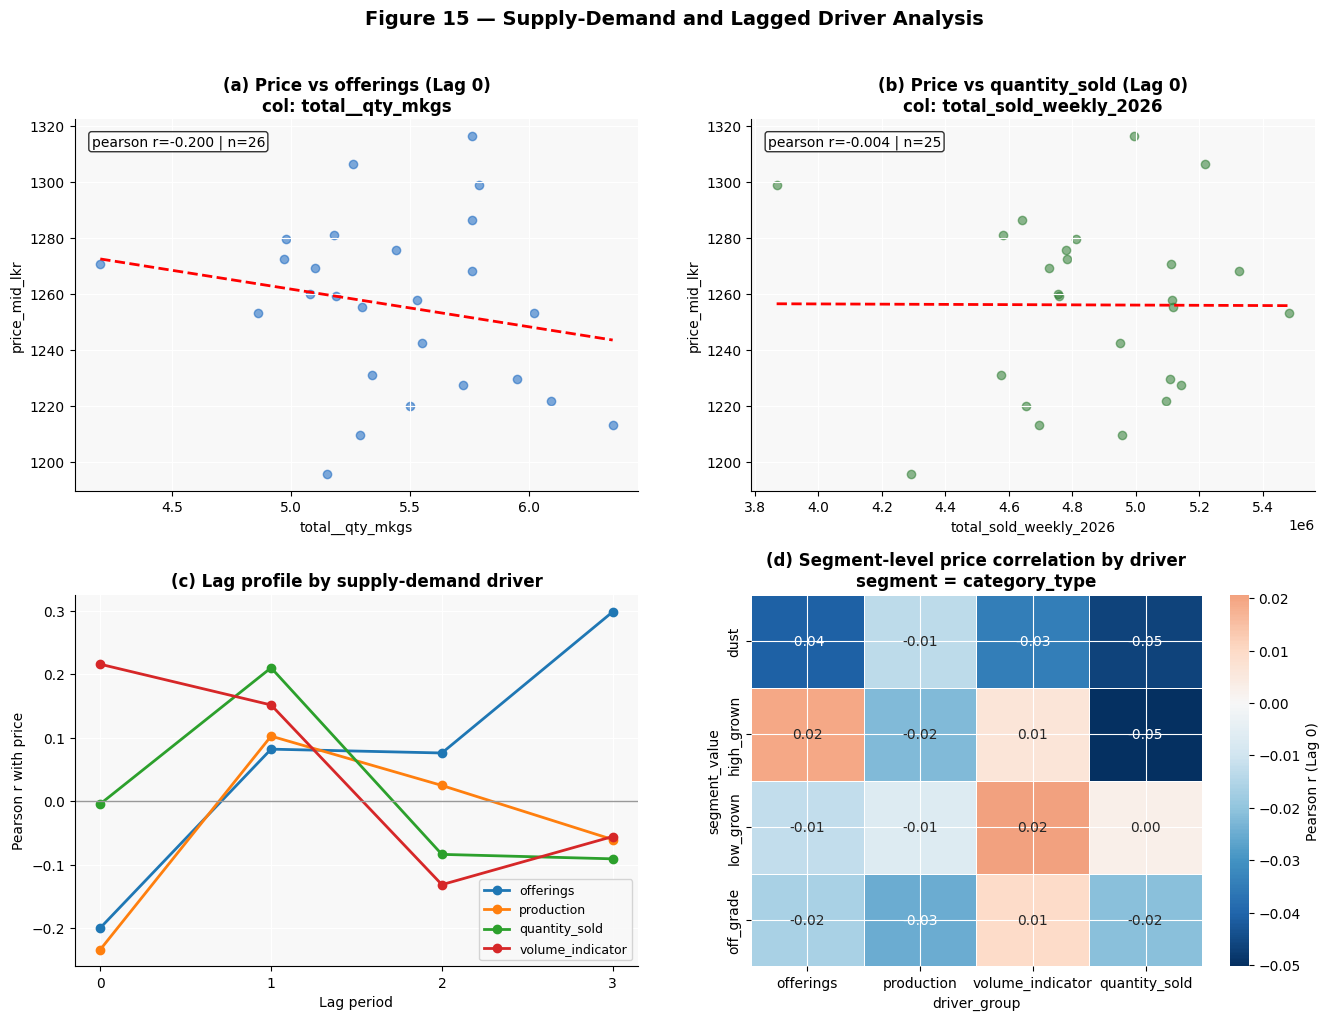

Figure 15 saved: /home/thilokya/Desktop/data-analysis-for-tea-industry/reports/figures/fig15_supply_demand_lags.png | exists=True

Strongest lag association (absolute Pearson):
driver_group          offerings
driver_col      total__qty_mkgs
lag_period                    3
pearson_r              0.298132
spearman_r             0.329377
n_obs                        23

Top segment-level Lag0 correlations (absolute Pearson):
     segment_dim segment_value     driver_group             driver_col  pearson_r_lag0  spearman_r_lag0  n_obs
           grade           opa        offerings        total__qty_mkgs       -0.128641        -0.162036    104
           grade          pek1        offerings        total__qty_mkgs       -0.108200        -0.151928    104
           grade         fbopf volume_indicator  volume_yoy_change_pct        0.086340         0.069189    100
           grade           opa    quantity_sold total_sold_weekly_2026       -0.083632        -0.101591    100
           grade   

In [11]:
# Figure 15 — Supply-demand scatter and lag-correlation diagnostics
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.20)
fig.suptitle('Figure 15 — Supply-Demand and Lagged Driver Analysis', fontsize=14, fontweight='bold', y=0.98)

selected_items = list(selected_vars.items())

# Pick two main drivers for scatter panels (prefer offerings + quantity_sold if available)
preferred_order = ['offerings', 'quantity_sold', 'production', 'volume_indicator']
scatter_groups = [g for g in preferred_order if g in selected_vars]
for g, _ in selected_items:
    if g not in scatter_groups:
        scatter_groups.append(g)
scatter_groups = scatter_groups[:2]

# (a) Scatter 1
ax1 = fig.add_subplot(gs[0, 0])
if len(scatter_groups) >= 1:
    g1 = scatter_groups[0]
    c1 = selected_vars[g1]
    s1 = sale_level[[c1, target_col]].dropna()
    ax1.scatter(s1[c1], s1[target_col], alpha=0.55, s=36, color='#1565C0')
    if len(s1) >= 3:
        z = np.polyfit(s1[c1], s1[target_col], 1)
        p = np.poly1d(z)
        xr = np.linspace(s1[c1].min(), s1[c1].max(), 100)
        ax1.plot(xr, p(xr), 'r--', linewidth=2)
    r1 = s1[target_col].corr(s1[c1], method='pearson') if len(s1) >= 3 else np.nan
    ax1.set_title(f'(a) Price vs {g1} (Lag 0)\ncol: {c1}', fontweight='bold')
    ax1.set_xlabel(c1)
    ax1.set_ylabel(target_col)
    ax1.text(0.03, 0.93, f'pearson r={r1:.3f} | n={len(s1)}', transform=ax1.transAxes,
             fontsize=10, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
else:
    ax1.text(0.5, 0.5, 'No driver available', ha='center', va='center')
    ax1.axis('off')

# (b) Scatter 2
ax2 = fig.add_subplot(gs[0, 1])
if len(scatter_groups) >= 2:
    g2 = scatter_groups[1]
    c2 = selected_vars[g2]
    s2 = sale_level[[c2, target_col]].dropna()
    ax2.scatter(s2[c2], s2[target_col], alpha=0.55, s=36, color='#2E7D32')
    if len(s2) >= 3:
        z = np.polyfit(s2[c2], s2[target_col], 1)
        p = np.poly1d(z)
        xr = np.linspace(s2[c2].min(), s2[c2].max(), 100)
        ax2.plot(xr, p(xr), 'r--', linewidth=2)
    r2 = s2[target_col].corr(s2[c2], method='pearson') if len(s2) >= 3 else np.nan
    ax2.set_title(f'(b) Price vs {g2} (Lag 0)\ncol: {c2}', fontweight='bold')
    ax2.set_xlabel(c2)
    ax2.set_ylabel(target_col)
    ax2.text(0.03, 0.93, f'pearson r={r2:.3f} | n={len(s2)}', transform=ax2.transAxes,
             fontsize=10, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
else:
    ax2.text(0.5, 0.5, 'Only one driver available', ha='center', va='center')
    ax2.axis('off')

# (c) Lag correlation profile (Pearson)
ax3 = fig.add_subplot(gs[1, 0])
plot_lag = lag_summary.dropna(subset=['pearson_r']).copy()
if not plot_lag.empty:
    for grp, sub in plot_lag.groupby('driver_group'):
        sub = sub.sort_values('lag_period')
        ax3.plot(sub['lag_period'], sub['pearson_r'], marker='o', linewidth=2, label=grp)
    ax3.axhline(0, color='#999', linewidth=1)
    ax3.set_xticks([0, 1, 2, 3])
    ax3.set_xlabel('Lag period')
    ax3.set_ylabel('Pearson r with price')
    ax3.set_title('(c) Lag profile by supply-demand driver', fontweight='bold')
    ax3.legend(fontsize=9)
else:
    ax3.text(0.5, 0.5, 'No lag correlations available', ha='center', va='center')
    ax3.axis('off')

# (d) Segment-level comparison heatmap (category_type if available, else elevation)
ax4 = fig.add_subplot(gs[1, 1])
seg_plot = None
for seg_candidate in ['category_type', 'elevation', '_leaf_dust_group', 'grade']:
    if not segment_summary.empty and seg_candidate in segment_summary['segment_dim'].unique():
        seg_plot = segment_summary[segment_summary['segment_dim'] == seg_candidate].copy()
        break

if seg_plot is not None and not seg_plot.empty:
    top_driver_order = (lag_summary.assign(abs_r=lag_summary['pearson_r'].abs())
                        .sort_values('abs_r', ascending=False)['driver_group']
                        .dropna().drop_duplicates().tolist())
    seg_plot['driver_group'] = pd.Categorical(seg_plot['driver_group'], categories=top_driver_order, ordered=True)
    heat = seg_plot.pivot_table(index='segment_value', columns='driver_group', values='pearson_r_lag0', aggfunc='mean')
    sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5,
                cbar_kws={'label': 'Pearson r (Lag 0)'}, ax=ax4)
    ax4.set_title(f'(d) Segment-level price correlation by driver\nsegment = {seg_plot["segment_dim"].iloc[0]}', fontweight='bold')
    ax4.set_xlabel('driver_group')
    ax4.set_ylabel('segment_value')
else:
    ax4.text(0.5, 0.5, 'No segment summary available', ha='center', va='center')
    ax4.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.965])
out_fig = FIGURES_DIR / 'fig15_supply_demand_lags.png'
plt.savefig(out_fig, dpi=160, bbox_inches='tight')
plt.show()

print(f'Figure 15 saved: {out_fig.resolve()} | exists={out_fig.exists()}')

# concise diagnostics for interpretation
if not lag_summary.dropna(subset=['pearson_r']).empty:
    best = lag_summary.dropna(subset=['pearson_r']).assign(abs_r=lambda d: d['pearson_r'].abs()).sort_values('abs_r', ascending=False).iloc[0]
    print('\nStrongest lag association (absolute Pearson):')
    print(best[['driver_group', 'driver_col', 'lag_period', 'pearson_r', 'spearman_r', 'n_obs']].to_string())

if not segment_summary.empty:
    seg_top = segment_summary.dropna(subset=['pearson_r_lag0']).assign(abs_r=lambda d: d['pearson_r_lag0'].abs()).sort_values('abs_r', ascending=False).head(10)
    print('\nTop segment-level Lag0 correlations (absolute Pearson):')
    print(seg_top[['segment_dim', 'segment_value', 'driver_group', 'driver_col', 'pearson_r_lag0', 'spearman_r_lag0', 'n_obs']].to_string(index=False))

### Interpretation: Supply-Demand and Lagged Market Drivers

- This section compares **current-period** and **lagged (1–3)** supply-side indicators against auction mid-price.
- If lagged correlations exceed lag-0 for a driver, that suggests delayed market transmission consistent with auction-cycle dynamics.
- Segment heatmaps (for available segment dimensions) indicate whether relationships are uniform or concentrated in specific market slices.

**How to read responsibly**
- These are **descriptive correlations only** and do not establish causality.
- Correlations can be sensitive to sample size, repeated records per sale, and unobserved confounders (weather shocks, currency, policy, demand substitutions).
- Findings should be treated as suggestive signals for future modeling, not as standalone predictive claims.

## FX-Normalized Price and Sentiment Interaction Analysis

This section extends the simple LKR-vs-USD comparison by explicitly analyzing whether broker/news sentiment relationships change when prices are viewed in:

- nominal LKR space
- FX-normalized (USD) space

It also checks whether effects differ by segment and by currency regime (weak vs strong LKR periods), while keeping claims strictly descriptive.

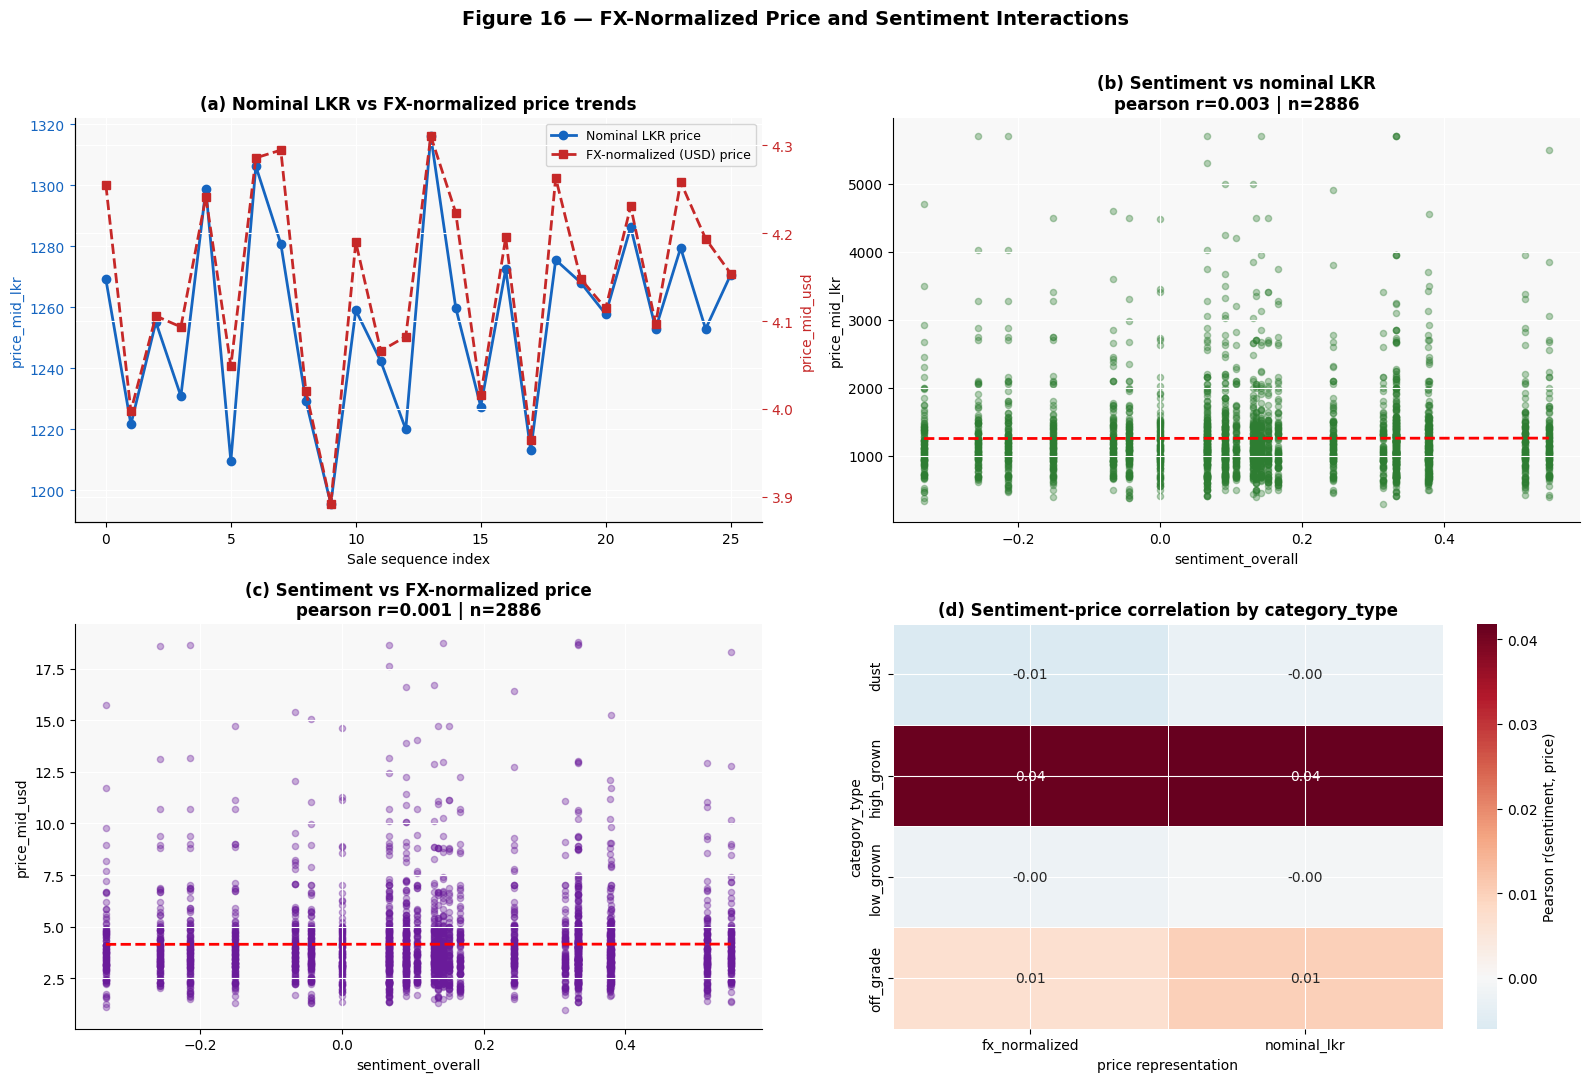

Selected variables:
  Nominal target      : price_mid_lkr
  FX-normalized price : price_mid_usd
  Sentiment feature   : sentiment_overall
  FX metric           : fx_usd_lkr_rate
  Ordering columns    : ['sale_year', 'sale_number'] + sale_date_raw
  Note                : Reused existing FX-normalized price: price_mid_usd

Figure 16 saved: /home/thilokya/Desktop/data-analysis-for-tea-industry/reports/figures/fig16_fx_sentiment_interactions.png | exists=True
Summary CSV saved: /home/thilokya/Desktop/data-analysis-for-tea-industry/data/Processed/fx_sentiment_interaction_summary.csv | exists=True

Overall sentiment-price correlations:
   comparison     price_col  n_obs  pearson_r  spearman_r
  nominal_lkr price_mid_lkr   2886   0.002508    0.006979
fx_normalized price_mid_usd   2886   0.001475    0.005351

FX-regime sentiment-price summary:
 fx_regime    comparison     price_col  n_obs  price_mean  sentiment_mean  pearson_r  spearman_r
       mid fx_normalized price_mid_usd    931    4.1477

In [12]:
# FX + sentiment interaction analysis (nominal vs FX-normalized)

# 1) Robust variable selection
lkr_target_col = 'price_mid_lkr' if 'price_mid_lkr' in df.columns else None
if lkr_target_col is None:
    raise ValueError('Missing nominal LKR target column: price_mid_lkr')

# Prefer already-normalized USD target if present
if 'price_mid_usd' in df.columns:
    fx_norm_col = 'price_mid_usd'
    fx_norm_note = 'Reused existing FX-normalized price: price_mid_usd'
else:
    # fallback: compute from LKR and USD/LKR exchange rate if available
    fx_rate_candidates = ['fx_usd_2026', 'fx_usd', 'usd_lkr_rate']
    fx_rate_col = next((c for c in fx_rate_candidates if c in df.columns), None)
    if fx_rate_col is None:
        raise ValueError('No FX-normalized price and no usable FX rate column found')
    fx_norm_col = 'price_fx_normalized_usd'
    dfr = df.copy()
    dfr[fx_norm_col] = np.where(dfr[fx_rate_col] > 0, dfr[lkr_target_col] / dfr[fx_rate_col], np.nan)
    df = dfr
    fx_norm_note = f'Computed FX-normalized price as {lkr_target_col} / {fx_rate_col}'

# Choose primary sentiment column from existing repo features
sentiment_candidates = [
    'sentiment_overall',
    'sentiment_ex_estate',
    'sentiment_low_grown',
    'low_grown__text_condition_score',
    'western_high__text_condition_score',
    'nuwara_eliya__text_condition_score',
    'uva_udapussellawa__text_condition_score',
]
sentiment_col = next((c for c in sentiment_candidates if c in df.columns), None)
if sentiment_col is None:
    raise ValueError('No sentiment-like feature found for interaction analysis')

# date/sale ordering columns
sale_cols = [c for c in ['sale_year', 'sale_number'] if c in df.columns]
date_col = 'sale_date_raw' if 'sale_date_raw' in df.columns else None

# FX regime column (weak vs strong LKR) using implied or direct USD/LKR rate
work = df.copy()
if 'fx_usd_2026' in work.columns:
    work['fx_usd_lkr_rate'] = work['fx_usd_2026']
elif 'price_mid_usd' in work.columns and 'price_mid_lkr' in work.columns:
    work['fx_usd_lkr_rate'] = np.where(work['price_mid_usd'] > 0, work['price_mid_lkr'] / work['price_mid_usd'], np.nan)
else:
    work['fx_usd_lkr_rate'] = np.nan

valid_rate = work['fx_usd_lkr_rate'].dropna()
if len(valid_rate) >= 10:
    lo_q, hi_q = valid_rate.quantile([0.33, 0.67])
    work['fx_regime'] = np.select(
        [
            work['fx_usd_lkr_rate'] >= hi_q,
            work['fx_usd_lkr_rate'] <= lo_q,
        ],
        ['weak_lkr', 'strong_lkr'],
        default='mid',
    )
else:
    work['fx_regime'] = 'unknown'

# 2) Core analysis frame
core_cols = [lkr_target_col, fx_norm_col, sentiment_col, 'fx_usd_lkr_rate', 'fx_regime'] + sale_cols
for c in ['elevation', 'category_type', 'grade', 'tier']:
    if c in work.columns:
        core_cols.append(c)
if date_col is not None:
    core_cols.append(date_col)
core_cols = list(dict.fromkeys(core_cols))
fx_df = work[core_cols].copy()
if date_col is not None:
    fx_df['_parsed_date'] = pd.to_datetime(fx_df[date_col], errors='coerce')

# 3) Trend table by sale order
sale_agg = {
    lkr_target_col: 'mean',
    fx_norm_col: 'mean',
    sentiment_col: 'mean',
    'fx_usd_lkr_rate': 'mean',
}
if date_col is not None:
    sale_agg['_parsed_date'] = 'min'
trend = fx_df.groupby(sale_cols, dropna=False).agg(sale_agg).reset_index()
if date_col is not None:
    trend = trend.sort_values(['_parsed_date'] + sale_cols).reset_index(drop=True)
else:
    trend = trend.sort_values(sale_cols).reset_index(drop=True)

# 4) Correlations: sentiment with nominal vs FX-normalized
corr_rows = []
for pair_name, price_col in [('nominal_lkr', lkr_target_col), ('fx_normalized', fx_norm_col)]:
    tmp = fx_df[[sentiment_col, price_col]].dropna()
    n = len(tmp)
    pear = tmp[sentiment_col].corr(tmp[price_col], method='pearson') if n >= 5 else np.nan
    spear = tmp[sentiment_col].corr(tmp[price_col], method='spearman') if n >= 5 else np.nan
    corr_rows.append({'comparison': pair_name, 'price_col': price_col, 'n_obs': n, 'pearson_r': pear, 'spearman_r': spear})

overall_corr = pd.DataFrame(corr_rows)

# 5) Segment breakdown correlations
segment_dims = [d for d in ['elevation', 'category_type', 'grade', 'tier'] if d in fx_df.columns]
segment_rows = []
for seg in segment_dims:
    for pair_name, price_col in [('nominal_lkr', lkr_target_col), ('fx_normalized', fx_norm_col)]:
        tmp = fx_df[[seg, sentiment_col, price_col]].dropna()
        if tmp.empty:
            continue
        for key, g in tmp.groupby(seg, dropna=False):
            if len(g) < 25:
                continue
            segment_rows.append({
                'segment_dim': seg,
                'segment_value': str(key),
                'comparison': pair_name,
                'price_col': price_col,
                'n_obs': int(len(g)),
                'pearson_r': g[sentiment_col].corr(g[price_col], method='pearson'),
                'spearman_r': g[sentiment_col].corr(g[price_col], method='spearman'),
            })
segment_corr = pd.DataFrame(segment_rows)

# 6) FX-regime grouped stats + correlations
regime_rows = []
for regime, g in fx_df.groupby('fx_regime', dropna=False):
    for pair_name, price_col in [('nominal_lkr', lkr_target_col), ('fx_normalized', fx_norm_col)]:
        t = g[[sentiment_col, price_col]].dropna()
        n = len(t)
        regime_rows.append({
            'fx_regime': str(regime),
            'comparison': pair_name,
            'price_col': price_col,
            'n_obs': n,
            'price_mean': t[price_col].mean() if n > 0 else np.nan,
            'sentiment_mean': t[sentiment_col].mean() if n > 0 else np.nan,
            'pearson_r': t[sentiment_col].corr(t[price_col], method='pearson') if n >= 5 else np.nan,
            'spearman_r': t[sentiment_col].corr(t[price_col], method='spearman') if n >= 5 else np.nan,
        })
regime_summary = pd.DataFrame(regime_rows)

# 7) Figure 16
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 16 — FX-Normalized Price and Sentiment Interactions', fontsize=14, fontweight='bold', y=0.98)

# (a) nominal vs FX-normalized trends by sale ordering
a = axes[0, 0]
x = np.arange(len(trend))
a.plot(x, trend[lkr_target_col], marker='o', linewidth=2, color='#1565C0', label='Nominal LKR price')
a2 = a.twinx()
a2.plot(x, trend[fx_norm_col], marker='s', linewidth=2, linestyle='--', color='#c62828', label='FX-normalized (USD) price')
a.set_title('(a) Nominal LKR vs FX-normalized price trends', fontweight='bold')
a.set_xlabel('Sale sequence index')
a.set_ylabel(lkr_target_col, color='#1565C0')
a2.set_ylabel(fx_norm_col, color='#c62828')
a.tick_params(axis='y', colors='#1565C0')
a2.tick_params(axis='y', colors='#c62828')
lines = [a.lines[0], a2.lines[0]]
a.legend(lines, [l.get_label() for l in lines], fontsize=9, loc='best')

# (b) sentiment vs nominal
b = axes[0, 1]
sn = fx_df[[sentiment_col, lkr_target_col]].dropna()
b.scatter(sn[sentiment_col], sn[lkr_target_col], alpha=0.35, s=20, color='#2E7D32')
if len(sn) >= 10:
    z = np.polyfit(sn[sentiment_col], sn[lkr_target_col], 1)
    p = np.poly1d(z)
    xs = np.linspace(sn[sentiment_col].min(), sn[sentiment_col].max(), 100)
    b.plot(xs, p(xs), 'r--', linewidth=2)
r_nom = sn[sentiment_col].corr(sn[lkr_target_col], method='pearson') if len(sn) >= 5 else np.nan
b.set_title(f'(b) Sentiment vs nominal LKR\npearson r={r_nom:.3f} | n={len(sn)}', fontweight='bold')
b.set_xlabel(sentiment_col)
b.set_ylabel(lkr_target_col)

# (c) sentiment vs FX-normalized
c = axes[1, 0]
sf = fx_df[[sentiment_col, fx_norm_col]].dropna()
c.scatter(sf[sentiment_col], sf[fx_norm_col], alpha=0.35, s=20, color='#6A1B9A')
if len(sf) >= 10:
    z = np.polyfit(sf[sentiment_col], sf[fx_norm_col], 1)
    p = np.poly1d(z)
    xs = np.linspace(sf[sentiment_col].min(), sf[sentiment_col].max(), 100)
    c.plot(xs, p(xs), 'r--', linewidth=2)
r_fx = sf[sentiment_col].corr(sf[fx_norm_col], method='pearson') if len(sf) >= 5 else np.nan
c.set_title(f'(c) Sentiment vs FX-normalized price\npearson r={r_fx:.3f} | n={len(sf)}', fontweight='bold')
c.set_xlabel(sentiment_col)
c.set_ylabel(fx_norm_col)

# (d) FX regime comparison of sentiment-price correlation
# choose category_type where possible; otherwise use regime summary bars
if not segment_corr.empty and 'category_type' in segment_corr['segment_dim'].unique():
    d = axes[1, 1]
    cat = segment_corr[segment_corr['segment_dim'] == 'category_type'].copy()
    heat = cat.pivot_table(index='segment_value', columns='comparison', values='pearson_r', aggfunc='mean')
    sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5,
                cbar_kws={'label': 'Pearson r(sentiment, price)'}, ax=d)
    d.set_title('(d) Sentiment-price correlation by category_type', fontweight='bold')
    d.set_xlabel('price representation')
    d.set_ylabel('category_type')
else:
    d = axes[1, 1]
    reg_plot = regime_summary[regime_summary['fx_regime'].isin(['strong_lkr', 'weak_lkr'])].copy()
    if not reg_plot.empty:
        sns.barplot(data=reg_plot, x='fx_regime', y='pearson_r', hue='comparison', ax=d)
        d.set_title('(d) Sentiment-price correlation by FX regime', fontweight='bold')
        d.set_ylabel('Pearson r')
        d.set_xlabel('FX regime')
    else:
        d.text(0.5, 0.5, 'No sufficient FX-regime data', ha='center', va='center')
        d.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.965])
out_fig16 = FIGURES_DIR / 'fig16_fx_sentiment_interactions.png'
plt.savefig(out_fig16, dpi=160, bbox_inches='tight')
plt.show()

# 8) Optional summary CSV export
summary_out = _ROOT / 'data' / 'Processed' / 'fx_sentiment_interaction_summary.csv'
summary_export = {
    'overall_corr': overall_corr,
    'regime_summary': regime_summary,
    'segment_corr': segment_corr,
}
# Flatten into one table with section label for easy team reuse
flat_parts = []
for section, table in summary_export.items():
    if table is not None and len(table) > 0:
        t = table.copy()
        t.insert(0, 'section', section)
        flat_parts.append(t)
if flat_parts:
    flat = pd.concat(flat_parts, ignore_index=True, sort=False)
    flat.to_csv(summary_out, index=False)

print('Selected variables:')
print(f'  Nominal target      : {lkr_target_col}')
print(f'  FX-normalized price : {fx_norm_col}')
print(f'  Sentiment feature   : {sentiment_col}')
print(f'  FX metric           : fx_usd_lkr_rate')
print(f'  Ordering columns    : {sale_cols}' + (f' + {date_col}' if date_col else ''))
print(f'  Note                : {fx_norm_note}')
print(f'\nFigure 16 saved: {out_fig16.resolve()} | exists={out_fig16.exists()}')
if flat_parts:
    print(f'Summary CSV saved: {summary_out.resolve()} | exists={summary_out.exists()}')

print('\nOverall sentiment-price correlations:')
print(overall_corr.to_string(index=False))

if not regime_summary.empty:
    print('\nFX-regime sentiment-price summary:')
    print(regime_summary.sort_values(['fx_regime', 'comparison']).to_string(index=False))

if not segment_corr.empty:
    top_seg = segment_corr.assign(abs_r=segment_corr['pearson_r'].abs()).sort_values('abs_r', ascending=False).head(12)
    print('\nTop segment-specific correlations (absolute Pearson):')
    print(top_seg[['segment_dim', 'segment_value', 'comparison', 'n_obs', 'pearson_r', 'spearman_r']].to_string(index=False))

### Interpretation: FX Effects and Sentiment Interactions

- Comparing nominal LKR and FX-normalized (USD) price views helps separate currency translation effects from underlying price dynamics.
- If sentiment correlation changes materially between LKR and USD space, that suggests part of the apparent sentiment signal may be FX-mediated.
- FX-regime summaries (weak vs strong LKR periods) indicate whether sentiment-price relationships are stable or context-dependent.
- Segment tables (elevation/category/grade/tier) should be read as exploratory heterogeneity checks, not causal evidence.
- If correlations are weak overall, that is still an informative result and should be reported directly rather than over-interpreted.

## Outlier, Volatility, and Anomaly Diagnostics

This section adds robust diagnostics for extreme auction prices and instability patterns that could affect downstream modeling.

What is covered:
- subgroup-aware outlier detection (IQR + robust z-score using MAD),
- sale-over-sale volatility diagnostics with rolling statistics,
- segment-level volatility comparison,
- top anomaly logging for research review.

All outputs remain descriptive and are not used for anomaly correction.

Diagnostics columns selected:
  target price        : price_mid_lkr
  ordering numeric    : ['sale_year', 'sale_number']
  ordering date       : sale_date_raw
  segmentation fields : ['elevation', 'category_type', 'grade', 'tier']


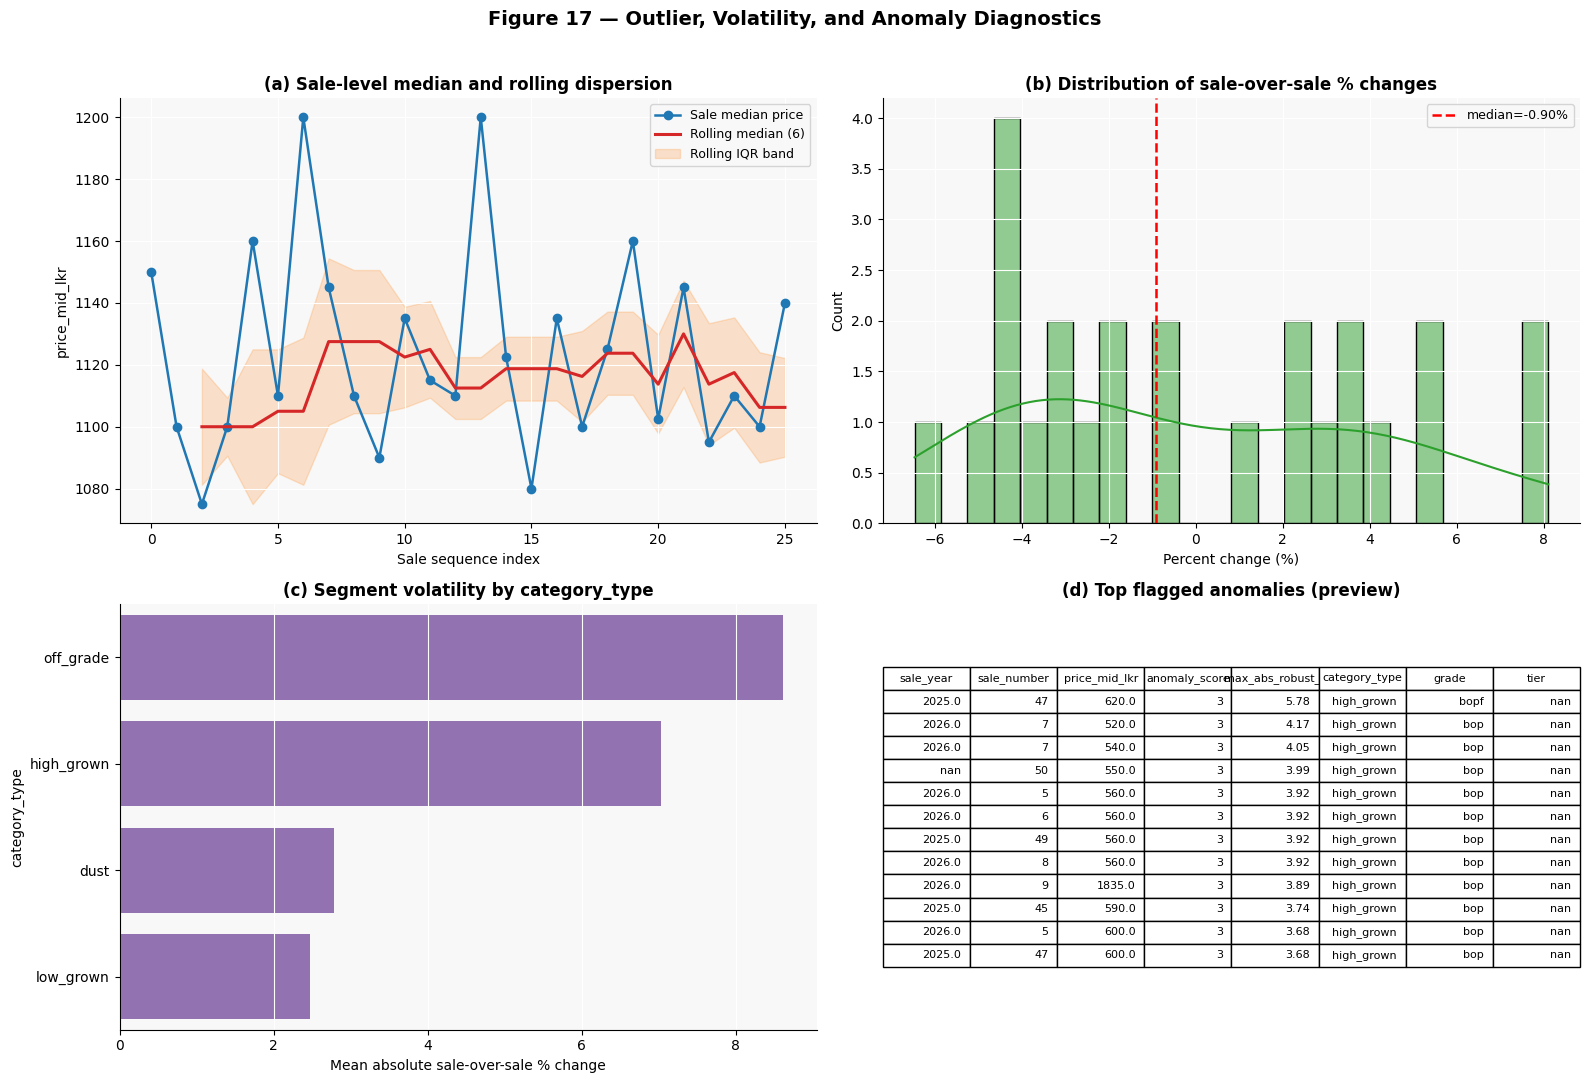


Outlier diagnostics summary:
  method                    : IQR (1.5*IQR fences) + robust z-score via MAD (|z| > 3.5)
  minimum group size        : 25
  grouping schemes used     : ['elevation_x_category_type', 'category_type_x_grade', 'grade_x_tier']
    - elevation_x_category_type: eligible_rows=3034, flagged_rows=152
    - category_type_x_grade: eligible_rows=3034, flagged_rows=50
    - grade_x_tier: eligible_rows=3034, flagged_rows=65

Volatility diagnostics summary:
  metrics: sale-over-sale % change, absolute % change, rolling median, rolling std, rolling IQR
  sale points analyzed      : 26
  segment volatility field  : category_type
category_type  n_sales  mean_abs_pct_change  std_pct_change  iqr_pct_change
    off_grade       26             8.619718       11.311816       12.063492
   high_grown       23             7.034265        9.929319        9.661924
         dust       26             2.784116        3.452429        4.301584
    low_grown       26             2.477878    

In [13]:
# Outlier + volatility diagnostics (descriptive only)

# 1) Identify required columns
price_candidates = ['price_mid_lkr', 'price_mid_usd', 'price_lo_lkr', 'price_hi_lkr']
price_col = next((c for c in price_candidates if c in df.columns), None)
if price_col is None:
    raise ValueError('No usable target price column found for diagnostics')

sale_num_cols = [c for c in ['sale_year', 'sale_number'] if c in df.columns]
date_col = 'sale_date_raw' if 'sale_date_raw' in df.columns else None
if not sale_num_cols and date_col is None:
    raise ValueError('No sale ordering columns found (need sale_year/sale_number and/or sale_date_raw)')

segment_candidates = ['elevation', 'category_type', 'grade', 'tier', 'estate']
segment_cols = [c for c in segment_candidates if c in df.columns]

print('Diagnostics columns selected:')
print(f'  target price        : {price_col}')
print(f'  ordering numeric    : {sale_num_cols}')
print(f'  ordering date       : {date_col}')
print(f'  segmentation fields : {segment_cols}')

# 2) Build ordered working table
work = df.copy()
if date_col is not None:
    work['_sale_date'] = pd.to_datetime(work[date_col], errors='coerce')
else:
    work['_sale_date'] = pd.NaT

sort_cols = []
if work['_sale_date'].notna().any():
    sort_cols.append('_sale_date')
sort_cols += sale_num_cols
if sort_cols:
    work = work.sort_values(sort_cols).reset_index(drop=True)

# sale-level series for volatility diagnostics
sale_group_cols = []
if 'sale_year' in work.columns:
    sale_group_cols.append('sale_year')
if 'sale_number' in work.columns:
    sale_group_cols.append('sale_number')
if not sale_group_cols and '_sale_date' in work.columns:
    sale_group_cols = ['_sale_date']

sale_level = work.groupby(sale_group_cols, dropna=False).agg(
    sale_price_mean=(price_col, 'mean'),
    sale_price_median=(price_col, 'median'),
    n_obs=(price_col, 'size'),
    sale_date=('_sale_date', 'min')
).reset_index()

sale_sort_cols = []
if 'sale_date' in sale_level.columns and sale_level['sale_date'].notna().any():
    sale_sort_cols.append('sale_date')
sale_sort_cols += [c for c in ['sale_year', 'sale_number'] if c in sale_level.columns]
if sale_sort_cols:
    sale_level = sale_level.sort_values(sale_sort_cols).reset_index(drop=True)

sale_level['sale_seq'] = np.arange(len(sale_level))
sale_level['pct_change'] = sale_level['sale_price_median'].pct_change() * 100.0
sale_level['abs_pct_change'] = sale_level['pct_change'].abs()
sale_level['diff_change'] = sale_level['sale_price_median'].diff()

roll_win = 6
sale_level['rolling_median'] = sale_level['sale_price_median'].rolling(roll_win, min_periods=3).median()
sale_level['rolling_std'] = sale_level['sale_price_median'].rolling(roll_win, min_periods=3).std()
sale_level['rolling_q75'] = sale_level['sale_price_median'].rolling(roll_win, min_periods=3).quantile(0.75)
sale_level['rolling_q25'] = sale_level['sale_price_median'].rolling(roll_win, min_periods=3).quantile(0.25)
sale_level['rolling_iqr'] = sale_level['rolling_q75'] - sale_level['rolling_q25']

# 3) Group-aware outlier flags (IQR + robust zscore/MAD)
def detect_group_outliers(data, value_col, group_cols, min_group_n=25):
    """Return robust outlier flags by subgroup with tiny-group protection."""
    out = pd.DataFrame(index=data.index)
    out['group_n'] = np.nan
    out['iqr_flag'] = False
    out['robust_flag'] = False
    out['robust_z'] = np.nan

    if not group_cols or any(c not in data.columns for c in group_cols):
        return out

    for _, idx in data.groupby(group_cols, dropna=False).groups.items():
        idx = list(idx)
        n = len(idx)
        out.loc[idx, 'group_n'] = n

        if n < min_group_n:
            continue

        x = data.loc[idx, value_col].astype(float)
        med = x.median()
        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)
        iqr = q3 - q1

        # IQR-based threshold only when spread is non-zero.
        if pd.notna(iqr) and iqr > 0:
            lo = q1 - 1.5 * iqr
            hi = q3 + 1.5 * iqr
            out.loc[idx, 'iqr_flag'] = (x < lo) | (x > hi)

        mad = (x - med).abs().median()
        if pd.notna(mad) and mad > 0:
            rz = 0.6745 * (x - med) / mad
            out.loc[idx, 'robust_z'] = rz
            out.loc[idx, 'robust_flag'] = rz.abs() > 3.5

    return out

scheme_specs = []
if all(c in work.columns for c in ['elevation', 'category_type']):
    scheme_specs.append(('elevation_x_category_type', ['elevation', 'category_type']))
if all(c in work.columns for c in ['category_type', 'grade']):
    scheme_specs.append(('category_type_x_grade', ['category_type', 'grade']))
if all(c in work.columns for c in ['grade', 'tier']):
    scheme_specs.append(('grade_x_tier', ['grade', 'tier']))

if not scheme_specs and 'category_type' in work.columns:
    scheme_specs.append(('category_type_only', ['category_type']))

min_group_n = 25
for scheme_name, group_cols in scheme_specs:
    out = detect_group_outliers(work, price_col, group_cols, min_group_n=min_group_n)
    work[f'{scheme_name}_group_n'] = out['group_n']
    work[f'{scheme_name}_iqr_flag'] = out['iqr_flag']
    work[f'{scheme_name}_robust_flag'] = out['robust_flag']
    work[f'{scheme_name}_robust_z'] = out['robust_z']
    work[f'{scheme_name}_any_flag'] = out['iqr_flag'] | out['robust_flag']

flag_cols = [c for c in work.columns if c.endswith('_any_flag')]
rz_cols = [c for c in work.columns if c.endswith('_robust_z')]

if flag_cols:
    work['anomaly_score'] = work[flag_cols].sum(axis=1)
else:
    work['anomaly_score'] = 0

if rz_cols:
    work['max_abs_robust_z'] = work[rz_cols].abs().max(axis=1, skipna=True)
else:
    work['max_abs_robust_z'] = np.nan

work['is_anomaly'] = work['anomaly_score'] > 0

# 4) Segment-level volatility comparisons
vol_segment = 'category_type' if 'category_type' in work.columns else (
    'elevation' if 'elevation' in work.columns else ('grade' if 'grade' in work.columns else None)
)

if vol_segment is not None:
    seg_series = work.groupby([vol_segment] + sale_group_cols, dropna=False).agg(
        seg_sale_median=(price_col, 'median')
    ).reset_index()

    seg_sort_cols = [vol_segment]
    if date_col is not None and '_sale_date' in work.columns:
        seg_dates = work.groupby([vol_segment] + sale_group_cols, dropna=False)['_sale_date'].min().reset_index(name='seg_date')
        seg_series = seg_series.merge(seg_dates, on=[vol_segment] + sale_group_cols, how='left')
        if seg_series['seg_date'].notna().any():
            seg_sort_cols.append('seg_date')
    seg_sort_cols += [c for c in ['sale_year', 'sale_number'] if c in seg_series.columns]
    seg_series = seg_series.sort_values(seg_sort_cols).reset_index(drop=True)

    seg_series['seg_pct_change'] = seg_series.groupby(vol_segment)['seg_sale_median'].pct_change() * 100.0
    seg_series['seg_abs_pct_change'] = seg_series['seg_pct_change'].abs()

    segment_vol = seg_series.groupby(vol_segment, dropna=False).agg(
        n_sales=('seg_sale_median', 'count'),
        mean_abs_pct_change=('seg_abs_pct_change', 'mean'),
        std_pct_change=('seg_pct_change', 'std'),
        iqr_pct_change=('seg_pct_change', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    ).reset_index()

    segment_vol = segment_vol[segment_vol['n_sales'] >= 8].sort_values('mean_abs_pct_change', ascending=False)
else:
    seg_series = pd.DataFrame()
    segment_vol = pd.DataFrame()

# 5) Compact anomaly table export
keep_cols = [price_col, 'anomaly_score', 'max_abs_robust_z', 'is_anomaly']
keep_cols += [c for c in ['sale_year', 'sale_number', 'sale_date_raw', 'elevation', 'category_type', 'grade', 'tier'] if c in work.columns]
anomaly_log = work[keep_cols].copy()
anomaly_log = anomaly_log[anomaly_log['is_anomaly']].sort_values(['anomaly_score', 'max_abs_robust_z'], ascending=False)
anomaly_log = anomaly_log.head(250)

anomaly_out = _ROOT / 'data' / 'Processed' / 'anomaly_log.csv'
anomaly_log.to_csv(anomaly_out, index=False)

# 6) Figure 17
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Figure 17 — Outlier, Volatility, and Anomaly Diagnostics', fontsize=14, fontweight='bold', y=0.98)

# (a) sale-level trend + rolling dispersion
ax = axes[0, 0]
ax.plot(sale_level['sale_seq'], sale_level['sale_price_median'], marker='o', linewidth=1.8, color='#1f77b4', label='Sale median price')
ax.plot(sale_level['sale_seq'], sale_level['rolling_median'], linewidth=2.2, color='#d62728', label=f'Rolling median ({roll_win})')

band_lo = sale_level['rolling_median'] - 0.5 * sale_level['rolling_iqr']
band_hi = sale_level['rolling_median'] + 0.5 * sale_level['rolling_iqr']
mask = band_lo.notna() & band_hi.notna()
if mask.any():
    ax.fill_between(sale_level.loc[mask, 'sale_seq'], band_lo[mask], band_hi[mask], alpha=0.20, color='#ff7f0e', label='Rolling IQR band')
ax.set_title('(a) Sale-level median and rolling dispersion', fontweight='bold')
ax.set_xlabel('Sale sequence index')
ax.set_ylabel(price_col)
ax.legend(loc='best', fontsize=9)

# (b) distribution of sale-over-sale changes
ax = axes[0, 1]
chg = sale_level['pct_change'].dropna()
if len(chg) > 0:
    sns.histplot(chg, bins=24, kde=True, color='#2ca02c', ax=ax)
    ax.axvline(chg.median(), color='red', linestyle='--', linewidth=1.8, label=f'median={chg.median():.2f}%')
    ax.legend(fontsize=9)
ax.set_title('(b) Distribution of sale-over-sale % changes', fontweight='bold')
ax.set_xlabel('Percent change (%)')
ax.set_ylabel('Count')

# (c) segment-level volatility comparison
ax = axes[1, 0]
if not segment_vol.empty and vol_segment is not None:
    topv = segment_vol.head(12).copy()
    sns.barplot(data=topv, x='mean_abs_pct_change', y=vol_segment, color='#9467bd', ax=ax)
    ax.set_title(f'(c) Segment volatility by {vol_segment}', fontweight='bold')
    ax.set_xlabel('Mean absolute sale-over-sale % change')
    ax.set_ylabel(vol_segment)
else:
    ax.text(0.5, 0.5, 'No sufficient segment-level volatility data', ha='center', va='center')
    ax.axis('off')

# (d) top anomalies table preview
ax = axes[1, 1]
show_cols = [c for c in ['sale_year', 'sale_number', price_col, 'anomaly_score', 'max_abs_robust_z', 'category_type', 'grade', 'tier'] if c in anomaly_log.columns]
show = anomaly_log[show_cols].head(12).copy()
if not show.empty:
    if price_col in show.columns:
        show[price_col] = show[price_col].round(1)
    if 'max_abs_robust_z' in show.columns:
        show['max_abs_robust_z'] = show['max_abs_robust_z'].round(2)
    tbl = ax.table(cellText=show.values, colLabels=show.columns, loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.0, 1.25)
    ax.set_title('(d) Top flagged anomalies (preview)', fontweight='bold')
    ax.axis('off')
else:
    ax.text(0.5, 0.5, 'No anomalies flagged with current thresholds', ha='center', va='center')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.965])
out_fig17 = FIGURES_DIR / 'fig17_outlier_volatility.png'
plt.savefig(out_fig17, dpi=160, bbox_inches='tight')
plt.show()

# 7) Diagnostic console summary
scheme_stats = []
for scheme_name, _ in scheme_specs:
    gn = work.get(f'{scheme_name}_group_n')
    fl = work.get(f'{scheme_name}_any_flag')
    if gn is None or fl is None:
        continue
    eligible = int((gn >= min_group_n).sum())
    flagged = int(fl.fillna(False).sum())
    scheme_stats.append((scheme_name, eligible, flagged))

print('\nOutlier diagnostics summary:')
print(f'  method                    : IQR (1.5*IQR fences) + robust z-score via MAD (|z| > 3.5)')
print(f'  minimum group size        : {min_group_n}')
print(f'  grouping schemes used     : {[name for name, _ in scheme_specs]}')
for name, eligible, flagged in scheme_stats:
    print(f'    - {name}: eligible_rows={eligible}, flagged_rows={flagged}')

print('\nVolatility diagnostics summary:')
print('  metrics: sale-over-sale % change, absolute % change, rolling median, rolling std, rolling IQR')
print(f'  sale points analyzed      : {len(sale_level)}')
if not segment_vol.empty and vol_segment is not None:
    print(f'  segment volatility field  : {vol_segment}')
    print(segment_vol.head(10).to_string(index=False))

print(f'\nFigure 17 saved: {out_fig17.resolve()} | exists={out_fig17.exists()}')
print(f'Anomaly log saved: {anomaly_out.resolve()} | exists={anomaly_out.exists()}')

if not anomaly_log.empty:
    print('\nTop anomalies (first 10 rows):')
    print(anomaly_log.head(10).to_string(index=False))

### Interpretation: Outlier, Volatility, and Anomaly Diagnostics

- Outlier flags are computed within market-relevant groups (not with one global cutoff), so extremes are interpreted relative to comparable auction segments.
- Rows flagged across multiple grouping schemes are stronger anomaly candidates than rows flagged in only one sparse subgroup.
- Some spikes can reflect genuine market stress, while others can come from thin-category samples or known reporting irregularities.
- This repo already documents a known Sale 3 volume anomaly in preprocessing; treat nearby extremes as contextual signals rather than automatic data errors.
- These diagnostics are for research reporting and modeling awareness only; they do not remove or correct observations.